# Example : Intermittency detection in decaying plasma turbulence simulation

For more details about the data, see [Ha et al. (2024)](https://arxiv.org/abs/2410.01878).

This example script can be found at `aweSOM/examples/plasma-turbulence/plasma.ipynb`.

To download the datasets used in this example, go to [https://doi.org/10.5281/zenodo.13909411](https://doi.org/10.5281/zenodo.13909411).

## Single aweSOM realization

The example hdf5 file, `features_2j1b1e0r_5000_jasym.h5`, contains 4 features, $j_{\parallel}$, $j_{\rm asym}$, $b_{\perp}$, and $e_{\parallel}$. Place the hdf5 file inside the `examples/plasma-turbulence/` directory and run the script.

To run a single SOM realization, use the `examples/plasma-turbulence/run_plasma_som.py` script with only one value
for each argument.

```bash
cd examples/plasma-turbulence
python run_plasma_som.py --ratio 0.6 --alpha_0 0.1 --train 2097152
```

This will train a SOM realization with an initial learning rate $\alpha_0 = 0.1$, a lattice ratio
$H = 0.6$, and $N = 2097152$ training steps (the entire simulation domain, $L^3 = 128^3$).

Optional toggles inside the script can be modified as needed. `file_name` points to the hdf5 file containing the
simulation snapshot, `sampling_type` can be either "uniform" (random initial weights between -1 and 1) or "sampling" (random initial weights sampled from the data), and `merge_threshold` sets the threshold of cost for merging two cluster centroids.

Two files will be generated: `som_object.*.pkl` and `labels.*.npy`. The former contains the trained SOM object
and the latter contains the cluster IDs for each data point. You can visualize the results following this example 
Jupyter notebook.

Also included on Zenodo is the fiducial SOM realization shown in [Ha et al. (2024)](https://arxiv.org/abs/2410.01878) under `som_object.fiducial-5000-64-37-0.1-2097152-1u.pkl`.


Load object to analyze

In [1]:
import aweSOM
from aweSOM import Lattice
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

path_to_object = aweSOM.__path__[0] + '/../../examples/plasma-turbulence/'
object_name = 'som_object.fiducial-5000-64-37-0.1-2097152-1u.pkl'

with open(path_to_object + object_name, 'rb') as f:
    map = pickle.load(f)

xdim = map.xdim
ydim = map.ydim

Visualize the U-matrix

Number of centroids: 23


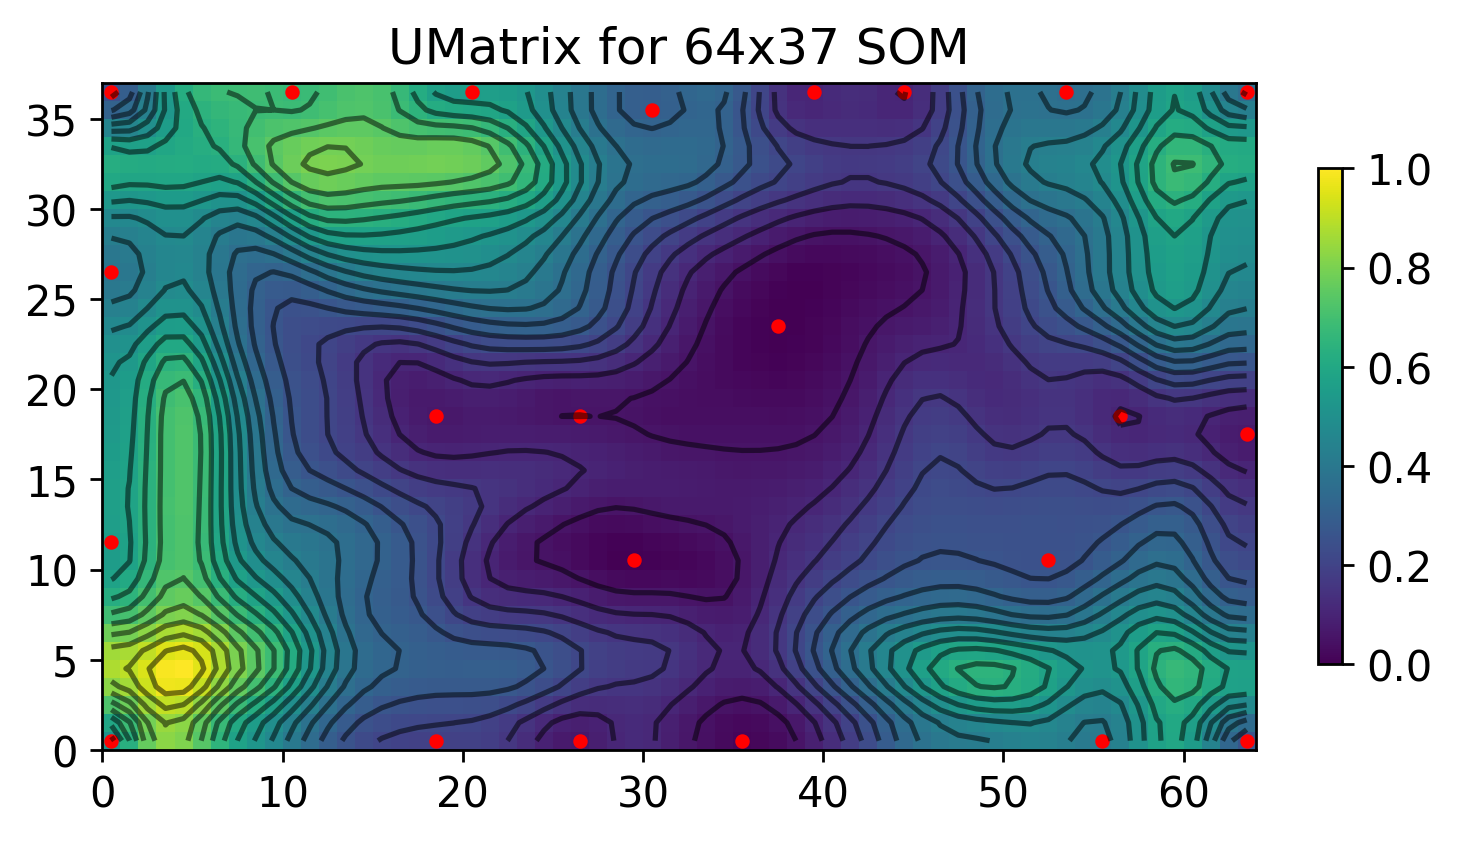

In [2]:
map.umat = map.compute_umat(smoothing=1)
unique_centroids = map.get_unique_centroids(map.compute_centroids())

unique_centroids['position_x'] = [x+0.5 for x in unique_centroids['position_x']]
unique_centroids['position_y'] = [y+0.5 for y in unique_centroids['position_y']]

X,Y = np.meshgrid(np.arange(xdim)+0.5, np.arange(ydim)+0.5)

plt.figure(dpi=250)
plt.pcolormesh(map.umat.T, cmap='viridis')
plt.scatter(unique_centroids['position_x'],unique_centroids['position_y'], color='red', s=10)
plt.colorbar(fraction=0.02)
plt.contour(X, Y, map.umat.T, levels=np.linspace(np.min(map.umat),np.max(map.umat), 20), colors='black', alpha=0.5)
plt.gca().set_aspect("equal")
plt.title(rf'UMatrix for {xdim}x{ydim} SOM')

print('Number of centroids:', len(unique_centroids['position_x']))

U-matrix history

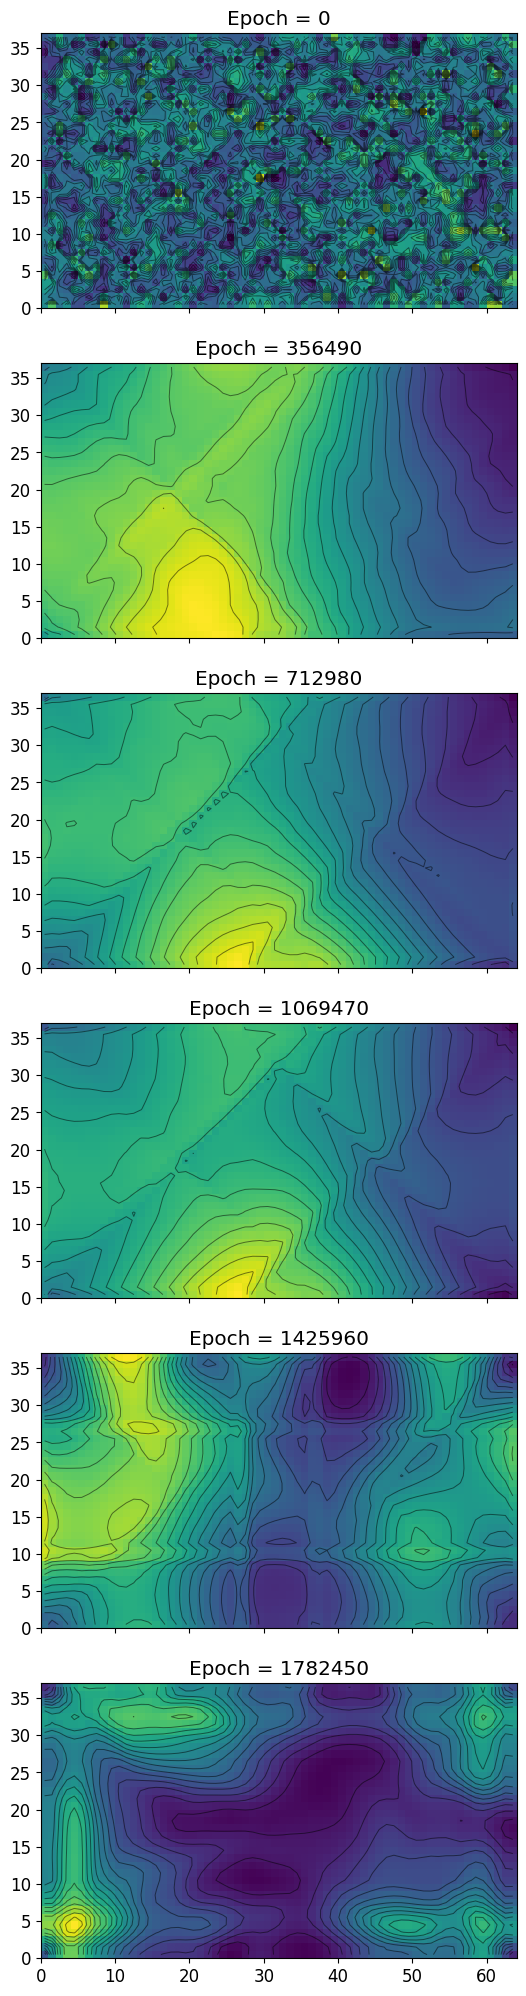

In [3]:
lattice_history = np.array(map.lattice_history)
umat_history = np.array(map.umat_history)
steps = np.linspace(0, lattice_history.shape[0] * map.save_frequency, lattice_history.shape[0], endpoint=False, dtype=int)

xdim = map.xdim
ydim = map.ydim
alpha_0 = map.alpha_0
train = map.train
X,Y = np.meshgrid(np.arange(xdim)+0.5, np.arange(ydim)+0.5)


num_plots = 6
fig, axs = plt.subplots(6, 1, figsize=(10, 25), sharex=True)
fig.subplots_adjust(hspace=0.2)
for i, k in enumerate(range(0, umat_history.shape[0], len(steps)//num_plots+1)):
    umat = umat_history[k]

    axs[i].title.set_text(f'Epoch = {steps[k]}')
    mesh = axs[i].pcolormesh(umat.T, cmap='viridis')
    axs[i].contour(X, Y, umat.T, levels=np.linspace(np.min(umat),np.max(umat), 20), colors='black', alpha=0.5, linewidths=0.7)
    axs[i].set_aspect("equal")


Spider plots to show the relative importance of each feature on the centroids of the identified clusters

In [4]:
plt.rcParams['font.size'] = 18
def plot_centroid_spider(loaded_som_object : Lattice, smoothing : float = None, merge_cost : float = 0.2):
    lattice_values = loaded_som_object.lattice

    # normalize the lattice values around its mean
    lattice_values = np.abs(lattice_values - lattice_values.mean(axis=0))

    mod_lattice_values = np.hstack((lattice_values, lattice_values[:,0].reshape(-1,1)))
    n_features = lattice_values.shape[1]
    features = loaded_som_object.features_names

    dict_lookup = {"j_mag" : r"$j$", "j_par" : r"$j_{\parallel}$", "j_perp" : r"$j_{\perp}$", "j_sym" : r"$j_{\rm s}$", "j_asym" : r"$j_{\rm a}$", "bz" : r"$b_z$", "b_perp" : r"$b_{\perp}$", "e_par" : r"$e_{\parallel}$", "e_perp" : r"$e_{\perp}$"}

    angles = [n / float(n_features) * 2 * np.pi for n in range(n_features)]
    angles += angles[:1]

    loaded_som_object.umat = loaded_som_object.compute_umat(smoothing=smoothing)
    naive_centroids = loaded_som_object.compute_centroids()
    merged_centroids = loaded_som_object.merge_similar_centroids(naive_centroids, threshold=merge_cost)
    unique_centroids = loaded_som_object.get_unique_centroids(merged_centroids)

    unique_centroids_coord = {}

    unique_centroids_coord['position_x'] = [x+0.5 for x in unique_centroids['position_x']]
    unique_centroids_coord['position_y'] = [y+0.5 for y in unique_centroids['position_y']]

    clusters = loaded_som_object.assign_cluster_to_lattice(smoothing=None,merge_cost=merge_cost)
    # numbering_clusters = list(range(len(unique_centroids['position_x'])))

    X,Y = np.meshgrid(np.arange(0,clusters.shape[0],1)+0.5, np.arange(0,clusters.shape[1],1)+0.5)
    dx=10/3
    umat = loaded_som_object.umat

    fig, ax1 = plt.subplots(dpi=300,)
    # ax1.axis('off')
    plt.pcolormesh(clusters.T, cmap='tab10', clim=[0,10], rasterized=True)
    # ax1.pcolormesh(umat.T, cmap='viridis')
    plt.scatter(unique_centroids_coord['position_x'],unique_centroids_coord['position_y'], color='white', s=18)
    # [plt.text(unique_centroids['position_x'][t]+1, unique_centroids['position_y'][t], numbering_clusters[t], color='k', fontsize=10) for t in range(len(numbering_clusters))]
    ax1.contour(X, Y, umat.T, levels=np.linspace(np.min(umat),(np.mean(umat)+np.min(umat))/2, 4), alpha=1, linewidths=0.7, colors='dimgray', linestyles='dotted')
    ax1.contour(X, Y, umat.T, levels=np.linspace((np.mean(umat)+np.min(umat))/2,np.mean(umat), 4), alpha=1, linewidths=0.7, colors='dimgray', linestyles='dashdot')
    ax1.contour(X, Y, umat.T, levels=np.linspace(np.mean(umat),(np.max(umat)+np.mean(umat))/2, 4), alpha=1, linewidths=0.7, colors='dimgray', linestyles='dashed')
    ax1.contour(X, Y, umat.T, levels=np.linspace((np.max(umat)+np.mean(umat))/2,np.max(umat), 4), alpha=1, linewidths=0.7, colors='dimgray', linestyles='solid')
    ax1.set_aspect("equal")
    ax1.set_title(f'{loaded_som_object.xdim}-{loaded_som_object.ydim}-{loaded_som_object.alpha_0}-{loaded_som_object.train} SOM')
    # ax1.set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    # ax1.set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax1.set_xlabel('X (node)')
    ax1.set_ylabel('Y (node)')

    for centroid_id in range(len(unique_centroids['position_x'])):
        row_values_of_centroids = [loaded_som_object.rowix(unique_centroids['position_x'][centroid_id], unique_centroids['position_y'][centroid_id])]
        
        # nrow = 2
        ncol = 3
        pos_x = [0.07, 0.37, 0.67]
        pos_y = [-0.25, -0.65, -1.05, -1.45, -1.85, -2.25]
        # pos_x = [1.1, 1.4, 1.7]
        # pos_y = [0.8, 0.3]
        position_of_subplot = pos_x[centroid_id % ncol], pos_y[centroid_id // ncol], 0.25, 0.25
        if centroid_id == 6:
            position_of_subplot = 0.3, 0.4, 0.25, 0.25
        ax2 = fig.add_axes(position_of_subplot, polar=True)
        ax2.set_xticks(angles[:-1], [dict_lookup[feature] for feature in features], color='black', size=17)
        ax2.set_rlabel_position(0)
        ax2.set_yticks([0, 0.6, 1.2], ["0", "0.6", "1.2"], color="dimgray", size=5)
        ax2.set_ylim(0.0,mod_lattice_values.max())
        # ax2.set_yscale('log')
        ax2.plot(angles, mod_lattice_values[row_values_of_centroids[0]], linewidth=1.5, linestyle='solid', color='black')
        ax2.fill(angles, mod_lattice_values[row_values_of_centroids[0]], 'k', alpha=0.3)
        ax2.set_facecolor(f'C{centroid_id}')
    
    plt.show()

Centroid A: (np.int64(39), np.int64(26)), count: 190
Centroid B: (np.int64(37), np.int64(23)), count: 376
Merging...
Centroid A: (np.int64(44), np.int64(35)), count: 40
Centroid B: (np.int64(39), np.int64(35)), count: 39
Merging...
Centroid A: (np.int64(25), np.int64(19)), count: 47
Centroid B: (np.int64(18), np.int64(18)), count: 400
Merging...
Centroid A: (np.int64(56), np.int64(18)), count: 100
Centroid B: (np.int64(63), np.int64(17)), count: 133
Merging...
Centroid A: (np.int64(35), np.int64(0)), count: 97
Centroid B: (np.int64(26), np.int64(0)), count: 55
Merging...
Centroid A: (np.int64(29), np.int64(10)), count: 259
Centroid B: (np.int64(35), np.int64(0)), count: 152
Merging...
Centroid A: (np.int64(49), np.int64(20)), count: 92
Centroid B: (np.int64(37), np.int64(23)), count: 566
Merging...


Centroid A: (np.int64(29), np.int64(10)), count: 411
Centroid B: (np.int64(37), np.int64(23)), count: 658
Merging...
Centroid A: (np.int64(44), np.int64(35)), count: 79
Centroid B: (np.int64(37), np.int64(23)), count: 1069
Merging...
Centroid A: (np.int64(18), np.int64(18)), count: 447
Centroid B: (np.int64(37), np.int64(23)), count: 1148
Merging...
Centroid A: (np.int64(48), np.int64(0)), count: 12
Centroid B: (np.int64(55), np.int64(0)), count: 36
Merging...
Centroid A: (np.int64(30), np.int64(35)), count: 56
Centroid B: (np.int64(37), np.int64(23)), count: 1595
Merging...
Centroid A: (np.int64(52), np.int64(10)), count: 72
Centroid B: (np.int64(63), np.int64(17)), count: 233
Merging...
Centroid A: (np.int64(0), np.int64(26)), count: 51
Centroid B: (np.int64(0), np.int64(19)), count: 22
Merging...
Centroid A: (np.int64(63), np.int64(0)), count: 19
Centroid B: (np.int64(55), np.int64(0)), count: 48
Merging...
Centroid A: (np.int64(63), np.int64(17)), count: 305
Centroid B: (np.int64(3

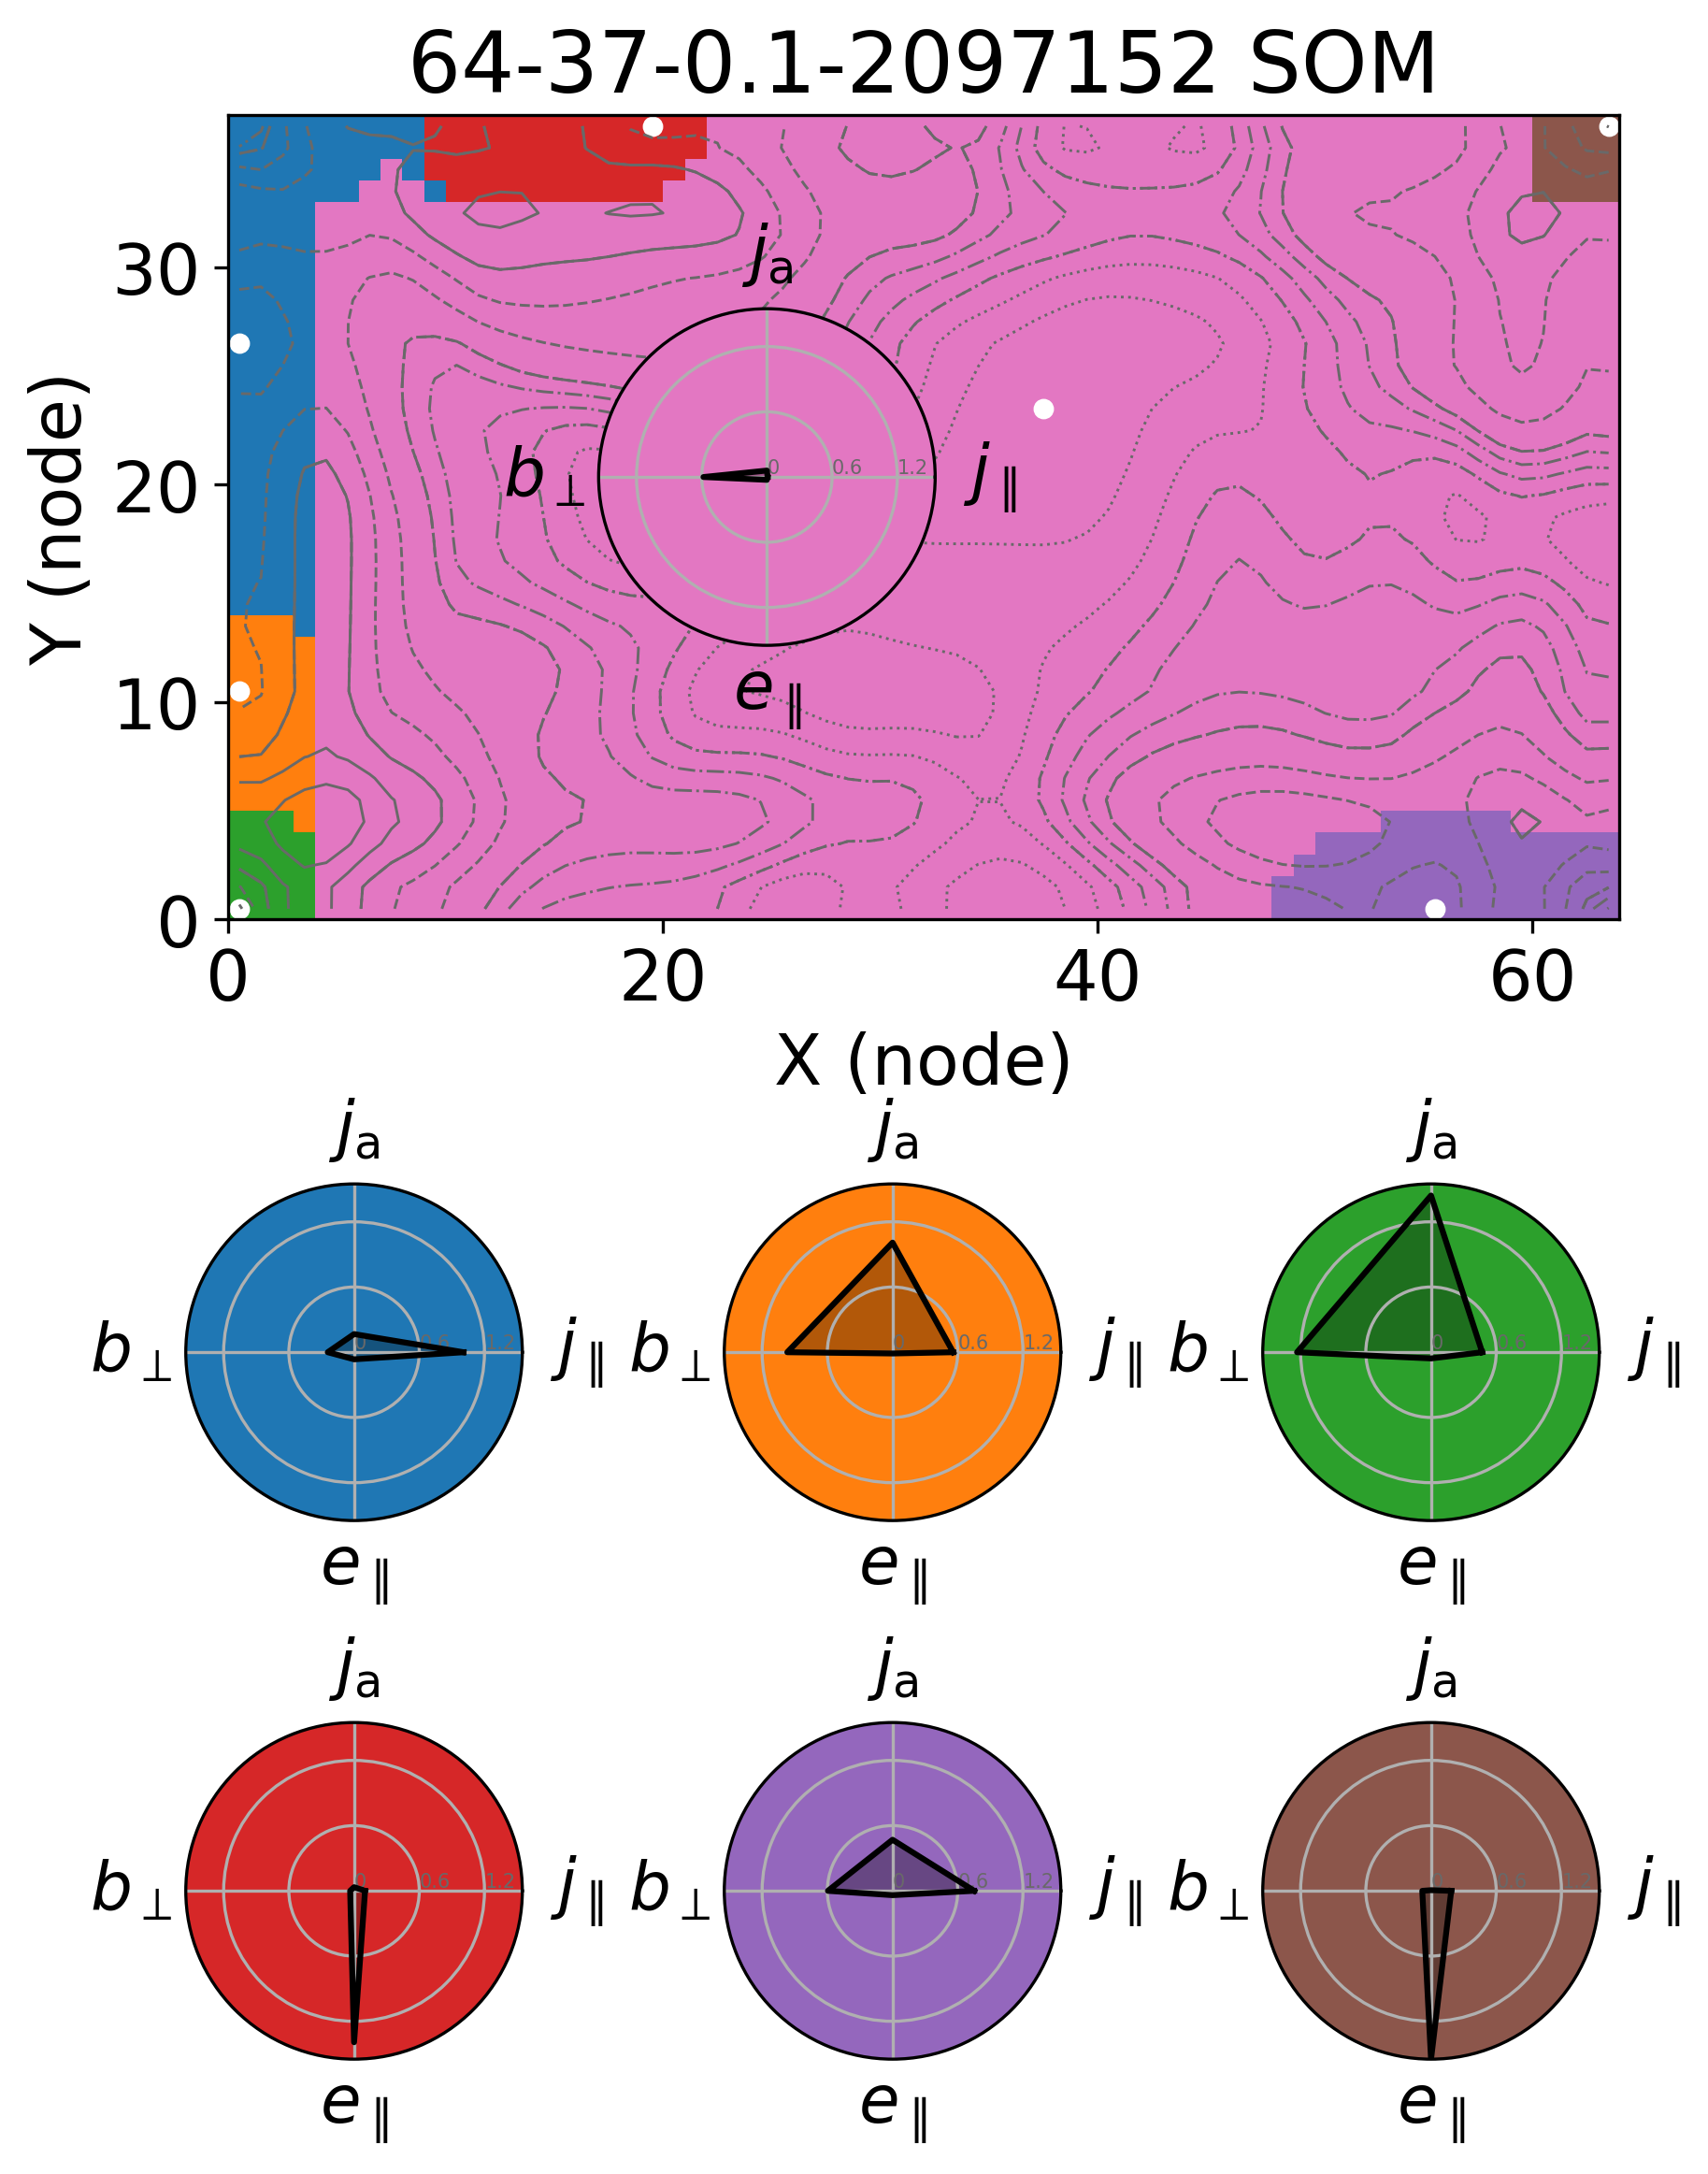

In [5]:
merge_cost = 0.25
smoothing = None # a number or None (cannot be 0)
plot_centroid_spider(map, smoothing=smoothing, merge_cost=merge_cost)

Map SOM result to data

In [6]:
final_clusters = map.assign_cluster_to_lattice(smoothing=smoothing, merge_cost=merge_cost)
som_labels = map.assign_cluster_to_data(map.projection_2d, final_clusters)

Centroid A: (np.int64(39), np.int64(26)), count: 190
Centroid B: (np.int64(37), np.int64(23)), count: 376
Merging...
Centroid A: (np.int64(44), np.int64(35)), count: 40
Centroid B: (np.int64(39), np.int64(35)), count: 39
Merging...
Centroid A: (np.int64(25), np.int64(19)), count: 47
Centroid B: (np.int64(18), np.int64(18)), count: 400
Merging...
Centroid A: (np.int64(56), np.int64(18)), count: 100
Centroid B: (np.int64(63), np.int64(17)), count: 133
Merging...
Centroid A: (np.int64(35), np.int64(0)), count: 97
Centroid B: (np.int64(26), np.int64(0)), count: 55
Merging...
Centroid A: (np.int64(29), np.int64(10)), count: 259
Centroid B: (np.int64(35), np.int64(0)), count: 152


Merging...
Centroid A: (np.int64(49), np.int64(20)), count: 92
Centroid B: (np.int64(37), np.int64(23)), count: 566
Merging...
Centroid A: (np.int64(29), np.int64(10)), count: 411
Centroid B: (np.int64(37), np.int64(23)), count: 658
Merging...
Centroid A: (np.int64(44), np.int64(35)), count: 79
Centroid B: (np.int64(37), np.int64(23)), count: 1069
Merging...
Centroid A: (np.int64(18), np.int64(18)), count: 447
Centroid B: (np.int64(37), np.int64(23)), count: 1148
Merging...
Centroid A: (np.int64(48), np.int64(0)), count: 12
Centroid B: (np.int64(55), np.int64(0)), count: 36
Merging...
Centroid A: (np.int64(30), np.int64(35)), count: 56
Centroid B: (np.int64(37), np.int64(23)), count: 1595
Merging...
Centroid A: (np.int64(52), np.int64(10)), count: 72
Centroid B: (np.int64(63), np.int64(17)), count: 233
Merging...
Centroid A: (np.int64(0), np.int64(26)), count: 51
Centroid B: (np.int64(0), np.int64(19)), count: 22
Merging...
Centroid A: (np.int64(63), np.int64(0)), count: 19
Centroid B:

Load simulation data to compare

You need two files for this step. First is the original hdf5 snapshot of the simulation, `flds_5000.h5`, second is the configuration file to read the snapshot, `d3x128s10.ini`. Put the `.ini` file inside `aweSOM/examples/plasma-turbulence/`, and the `.h5` file inside a subfolder `d3x128s10/`.

Download the files from the Zenodo archive, then provide the path to the files with `path`.

In [7]:
original_path = os.getcwd()
print('Current working directory:', original_path)

Current working directory: /mnt/home/tha10/git_repos/aweSOM/examples/plasma-turbulence


In [8]:
import read_turbulence_data as rtd
conf = "d3x128s10.ini"
path = '/mnt/home/tha10/ceph/sim_snapshots/'# "/Users/tvh0021/Documents/Archive/"
filename = "flds_5000.h5"
lap = 5000

decay_turb = rtd.GetH5Data(path, filename, conf, lap)
# get the data
dx = 10./3.
decay_turb.return_basic_j_fields(dx)
decay_turb.return_all_other_fields()

/mnt/home/tha10/git_repos/aweSOM/examples/plasma-turbulence/initialize_turbulence.py:175: RuntimeWarning: divide by zero encountered in scalar divide
  A = 0.1 * self.g0 / self.gammarad**2  # definition we use in Runko


d3x128s10
plotting j_par
flds


Visualize the SOM result vs. a xy-slice of the $j_{\parallel}$.

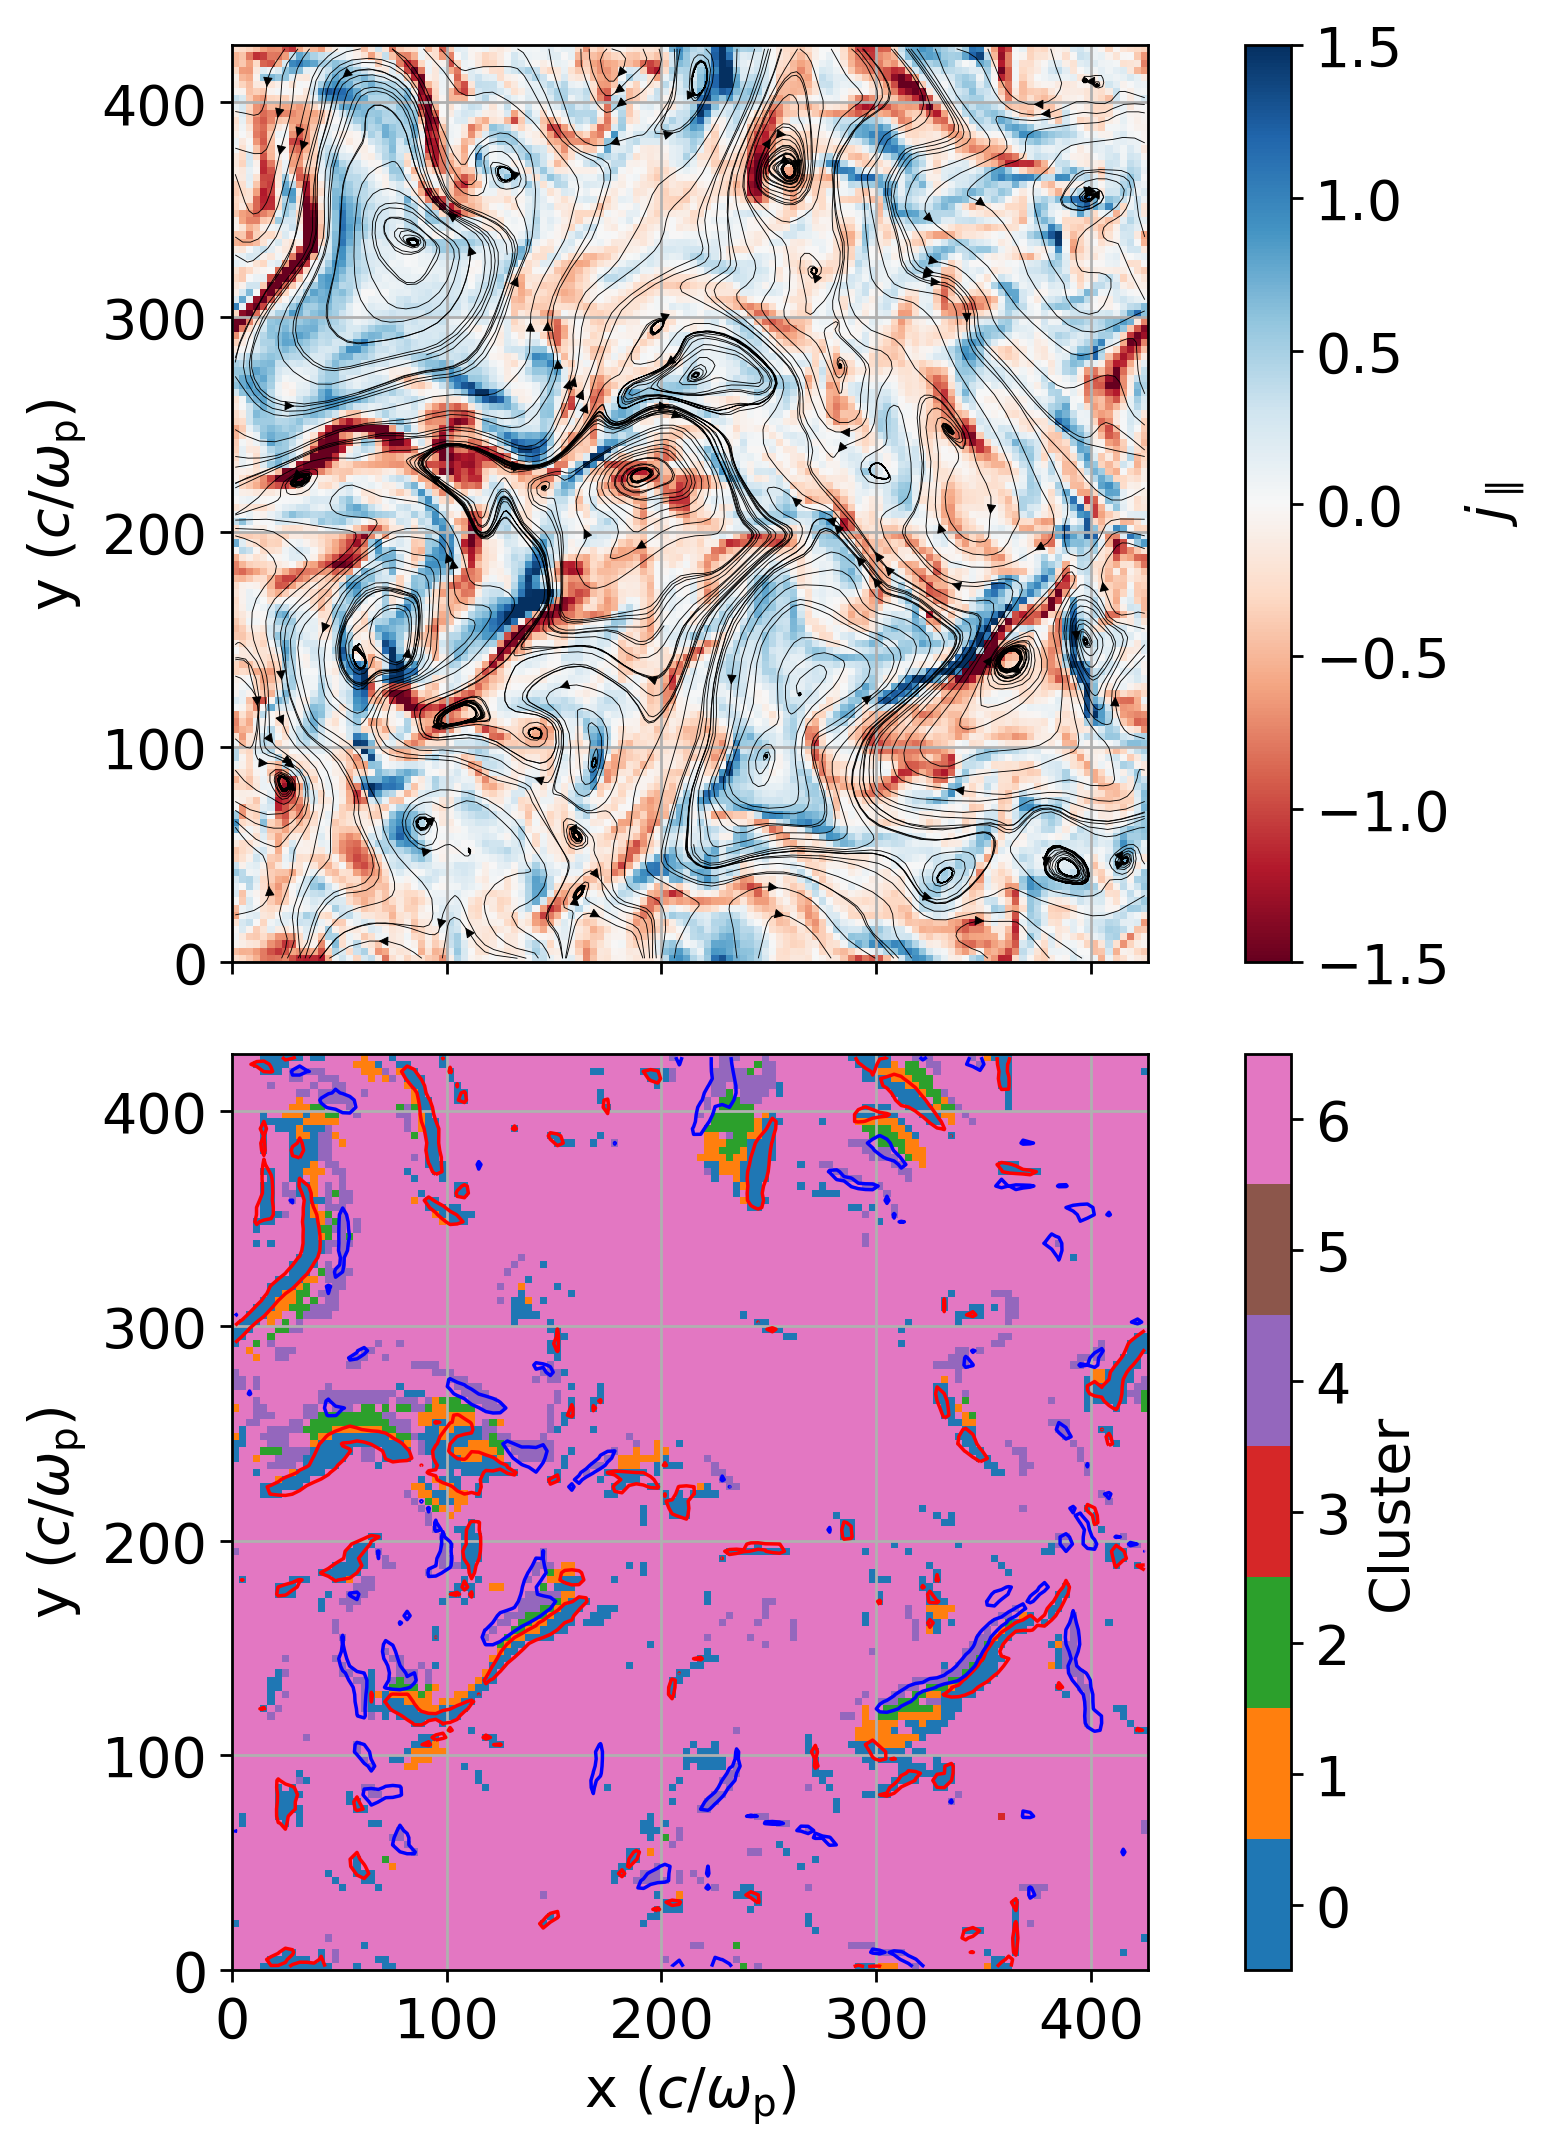

In [9]:
bx = decay_turb.bx
by = decay_turb.by
j_par = decay_turb.j_par
j_par_rms = np.sqrt(np.mean(j_par**2))
nx, ny, nz = decay_turb.nx, decay_turb.ny, decay_turb.nz
som_labels_transformed = som_labels.reshape((nz, ny, nx))

plt.rcParams.update({'font.size': 16})

slice_numbers = [27]

for slice_number in slice_numbers:
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=250, sharex=True)
    fig.subplots_adjust(hspace=0.1)

    jmag_plot = ax[0].pcolormesh(j_par[slice_number], cmap='RdBu', clim=[-1.5,1.5], rasterized=True)
    fig.colorbar(jmag_plot, ax=ax[0], fraction=0.042, pad=0.05, label=r'$j_{\parallel}$', ticks=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5], location="right")
    # ax[0].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors='green', linewidths=1, linestyles='solid')
    ax[0].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1., integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    # fig.colorbar(eperp_plot, ax=ax[0], fraction=0.042, pad=0.04, label=r'$E_{\perp}$', ticks=[0, 0.1, 0.2, 0.3])
    ax[0].set_aspect('equal', adjustable='box')
    ax[0].grid()
    # ax[0].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[0].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    # ax[0].set_xlabel(r'x ($c/\omega_p$)')
    ax[0].set_ylabel(r'y ($c/\omega_{\rm p}$)')
    # ax[0].set_title(f'z = {slice_number*dx:.0f} '+ r'$c/\omega_{\rm p}$')

    cluster_plot = ax[1].pcolormesh(som_labels_transformed[slice_number], cmap='tab10', clim=[0,10], rasterized=True)
    cbar = fig.colorbar(cluster_plot, ax=ax[1], fraction=0.042, pad=0.05, label='Cluster', ticks=np.arange(0, len(set(som_labels)))+0.5, boundaries=np.arange(0, len(set(som_labels))+1), location="right")
    cbar.ax.set_yticklabels(np.arange(0, len(set(som_labels))))
    ax[1].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
    # ax[1].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1, integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    ax[1].set_aspect('equal', adjustable='box')
    ax[1].grid()
    ax[1].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_xlabel(r'x ($c/\omega_{\rm p}$)')
    ax[1].set_ylabel(r'y ($c/\omega_{\rm p}$)')

    plt.show()

## Stacking multiple aweSOM realizations for SCE analysis

To run a set of SOM realizations, use the `examples/plasma-turbulence/run_plasma_som.py` script with multiple values for each argument. `run_plasma_som.py` uses the `multiprocessing` package, so the more cores available, the faster it should run.

You will also need the file `features_2j1b1e0r_5000_jasym.h5` from [link to file].

```bash
cd examples/plasma-turbulence
python run_plasma_som.py --ratio 0.6 0.8 1. --alpha_0 0.1 0.2 0.4 --train 1000000 2097152 4194304
```

Refer to `examples/slurm_scripts/submit_plasma.slurm` for an example of the SLURM submit script to run the parameter scan on a set of aweSOM realizations.

The result of this run is a list of files with names `labels.*` and `som_object.*`. The labels are final clustering results, while the objects are pickle files of the entire trained lattice that can be modified. Move all `labels.*` files into a subfolder named `som_results`.

Alternatively, you can use a set of pre-trained aweSOM realizations, which can be retrieved from the Zenodo archive, under `plasma-som-realizations.tar`. Unpack the files inside `aweSOM/examples/plasma-turbulence/som_results/`.


In [11]:
# original_path = os.getcwd()
print('Current working directory:', original_path)

Current working directory: /mnt/home/tha10/git_repos/aweSOM/examples/plasma-turbulence


In [12]:
import read_turbulence_data as rtd
conf = "d3x128s10.ini"
path = '/mnt/home/tha10/ceph/sim_snapshots/'# "/Users/tvh0021/Documents/Archive/"
filename = "flds_5000.h5"
lap = 5000

decay_turb = rtd.GetH5Data(path, filename, conf, lap)
# get the data
dx = 10./3.
decay_turb.return_basic_j_fields(dx)
decay_turb.return_all_other_fields()

/mnt/home/tha10/git_repos/aweSOM/examples/plasma-turbulence/initialize_turbulence.py:175: RuntimeWarning: divide by zero encountered in scalar divide
  A = 0.1 * self.g0 / self.gammarad**2  # definition we use in Runko


d3x128s10
plotting j_par
flds


To run the SCE clustering, import `cuda` to use GPU acceleration. GPU is not necessary for the Iris dataset but is absolutely necessary here ($N_{\rm iris} = 150$, $N_{\rm plasma} = 128^3$).

Run the SCE $G_{\rm sum}$ calculation with:

```bash
cd som_results
python [path_to_aweSOM]/aweSOM/src/aweSOM/sce.py --subfolder SCE --dims 2097152
```

Make sure that the first line of output is ``Using JAX for GPU computation``.

Refer to `examples/slurm_scripts/submit.gpu` for an example of the SLURM submit script to run the SCE analysis on a set of aweSOM realizations.

Using one NVIDIA V-100 GPU, this should not take more than 3 minutes to complete. All cluster masks and `multimap_mappings.txt` are saved in `SCE/`

Now visualize $G_{\rm sum}$

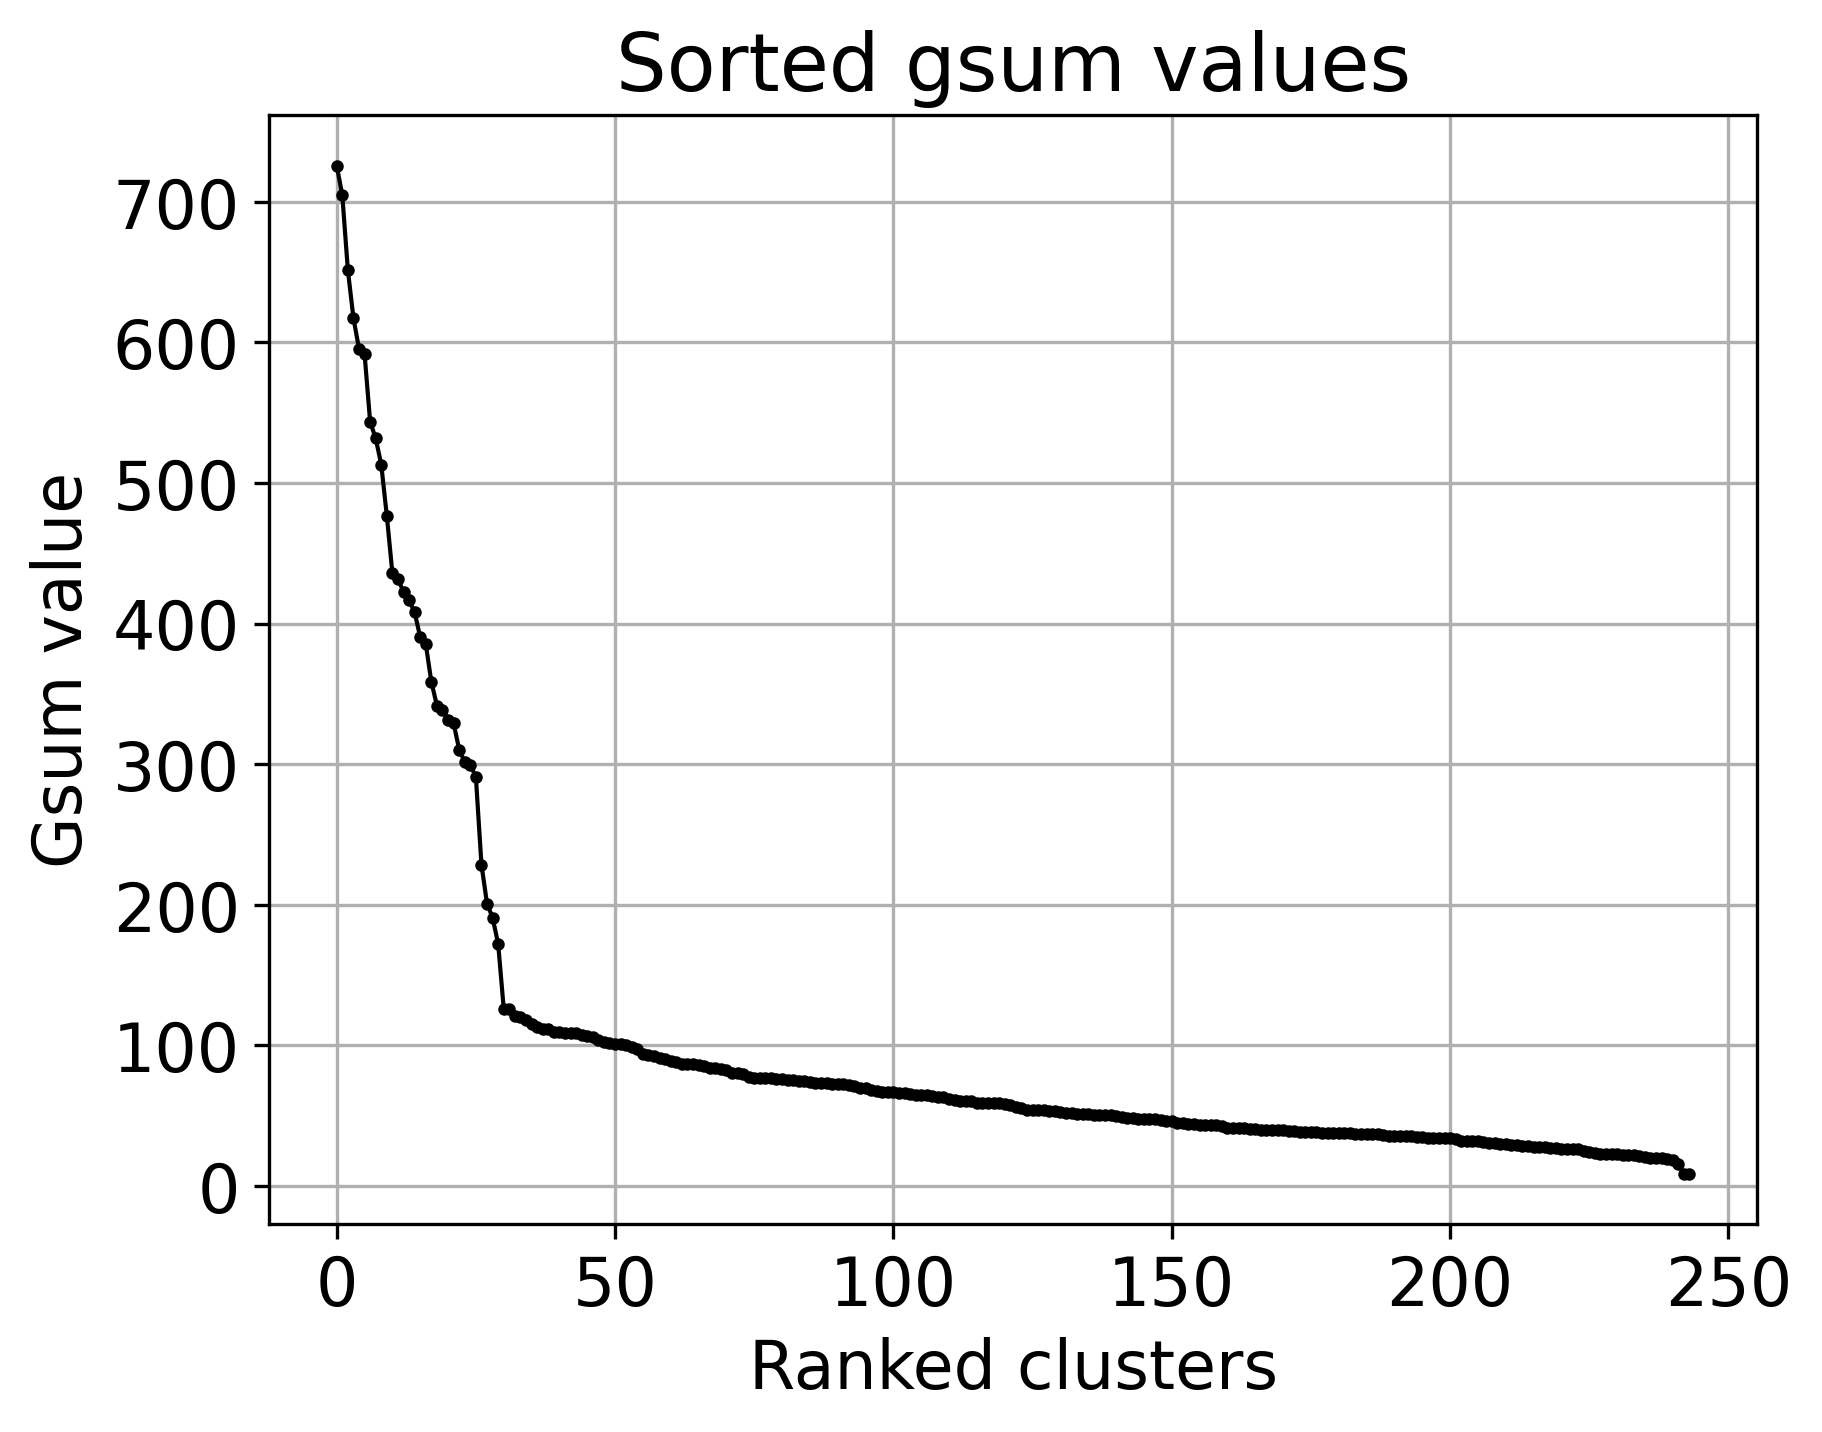

In [10]:
os.chdir(original_path) # recover the original path

file_path = 'som_results/SCE/'
file_name = 'multimap_mappings.txt'

from aweSOM.make_sce_clusters import get_gsum_values, plot_gsum_values

ranked_gsum_list, map_list = get_gsum_values(file_path+file_name)

plot_gsum_values(ranked_gsum_list)

In the simplest case, add all gsum values together to obtain final SCE clustering result

In [11]:
number_of_points = int(128**3)

sce_sum = np.zeros((number_of_points))

for i in range(len(ranked_gsum_list)):
    current_cluster_mask = np.load(f"{file_path}/mask-{map_list[i][2]}-id{map_list[i][1]}.npy")
    sce_sum += current_cluster_mask

Visualize the SCE stacking result

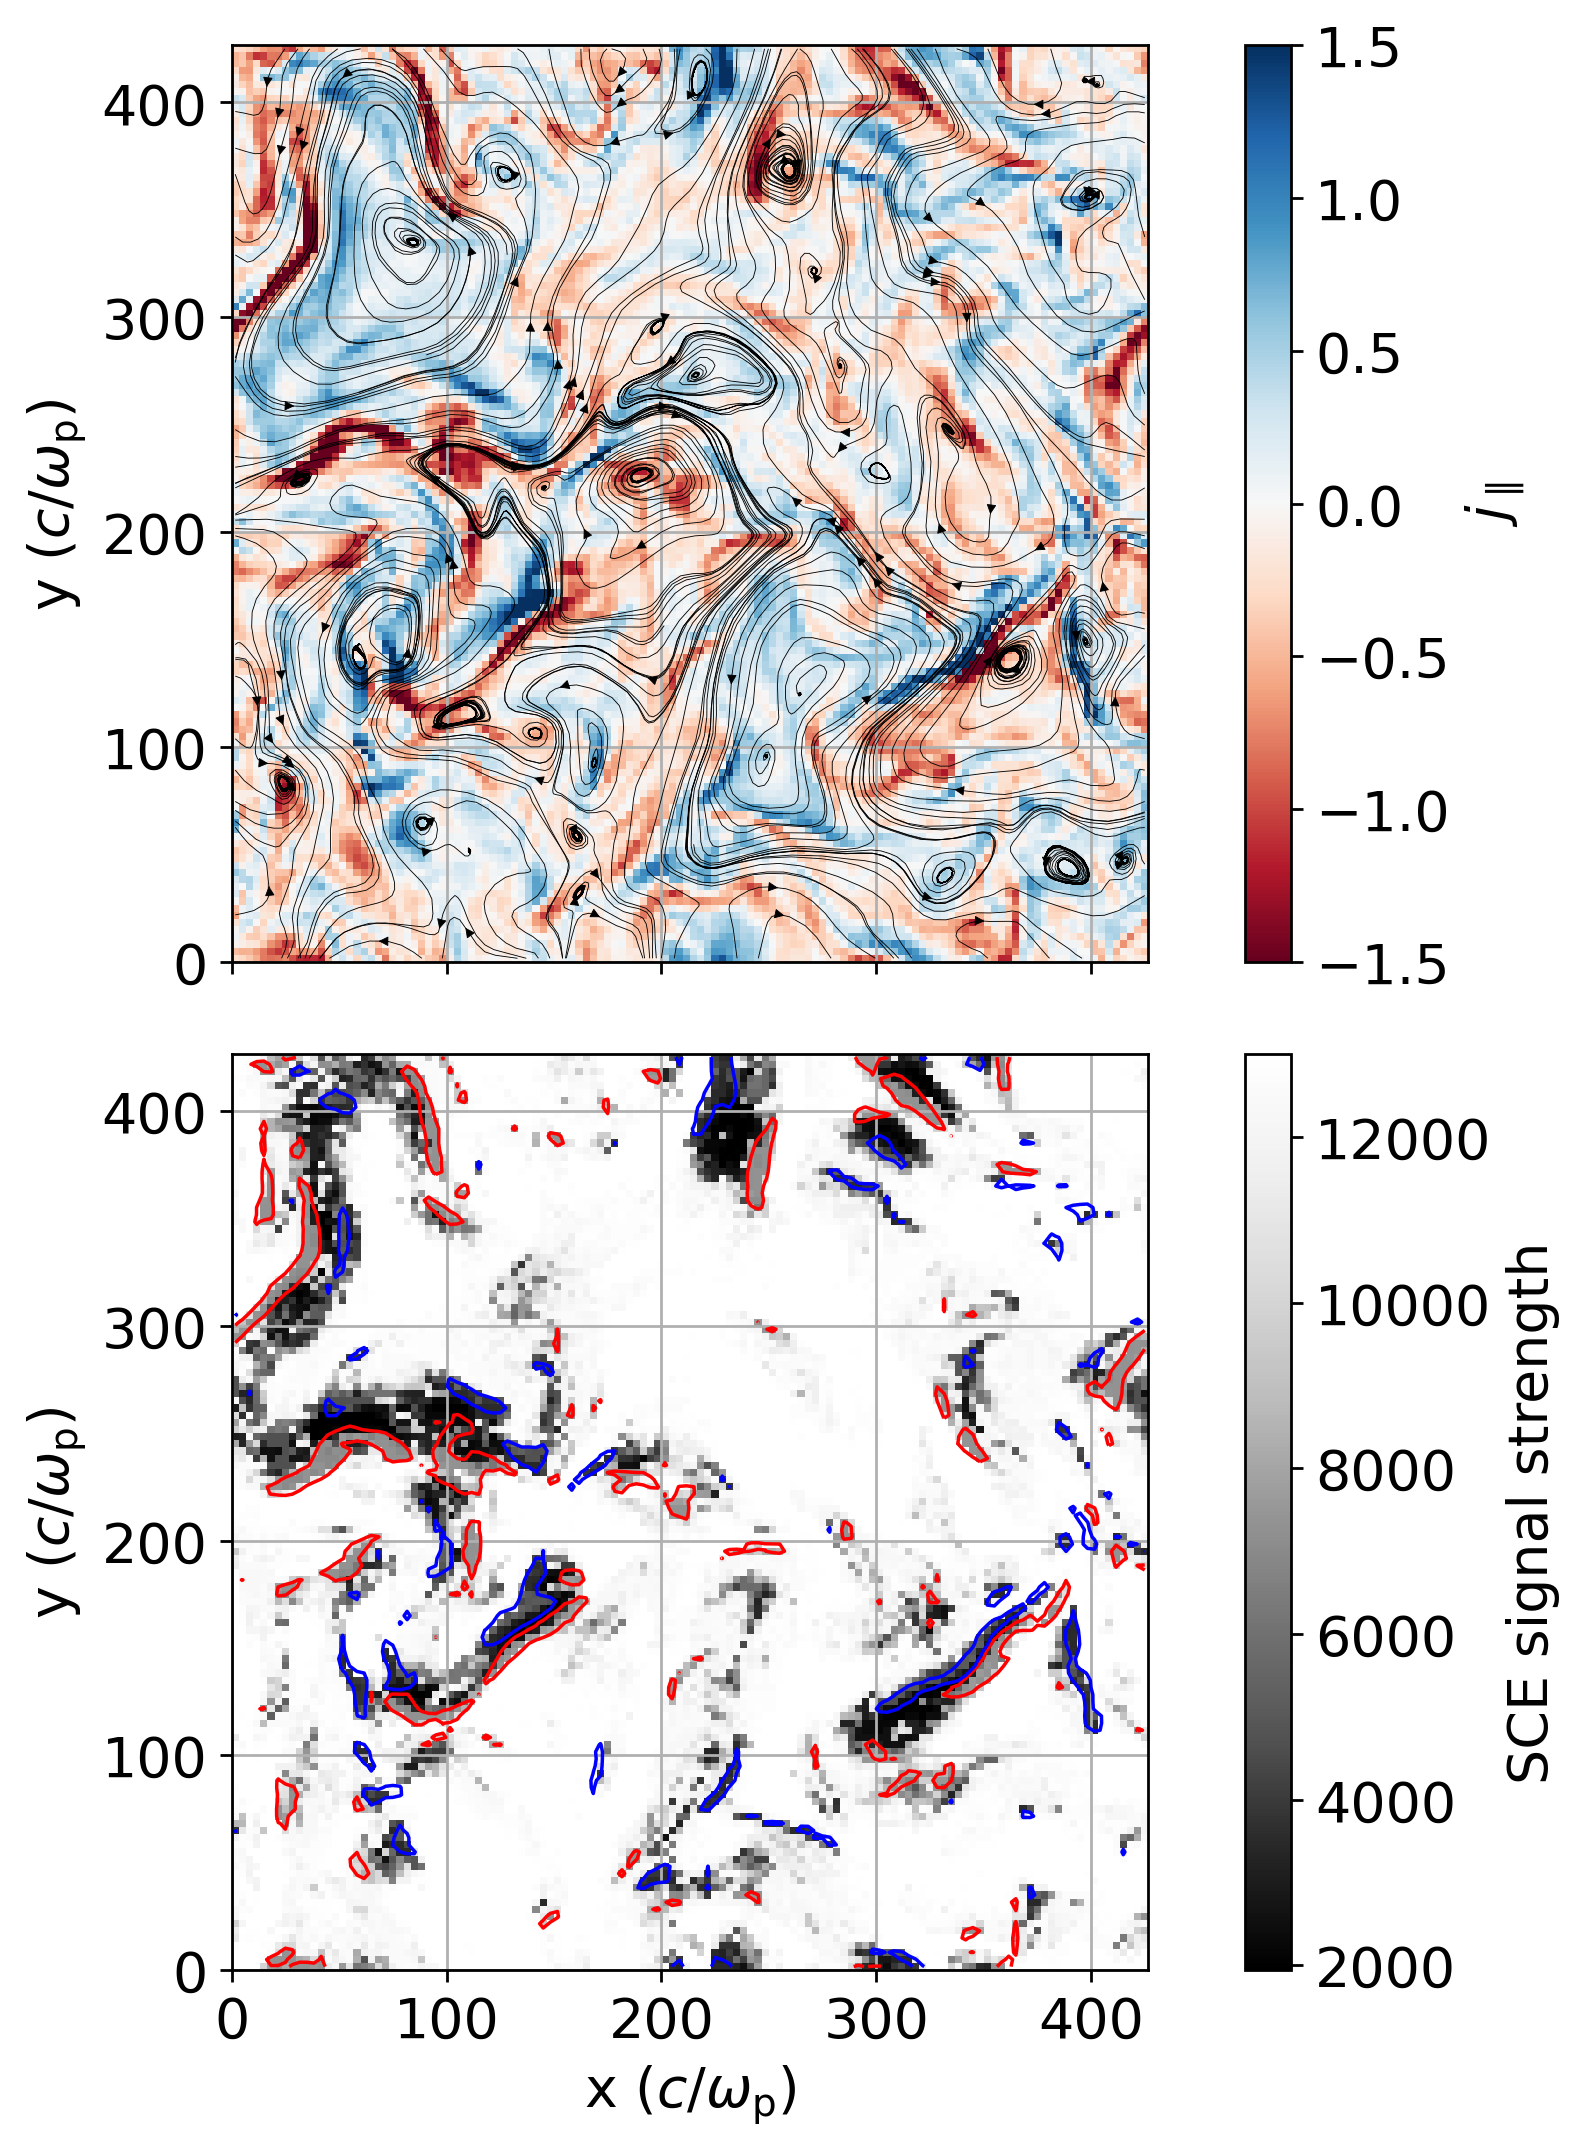

In [12]:
sce_sum_transformed = sce_sum.reshape((128,128,128))

slice_numbers = [27]

for slice_number in slice_numbers:
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=250, sharex=True)
    fig.subplots_adjust(hspace=0.1)

    jmag_plot = ax[0].pcolormesh(j_par[slice_number], cmap='RdBu', clim=[-1.5,1.5], rasterized=True)
    fig.colorbar(jmag_plot, ax=ax[0], fraction=0.042, pad=0.05, label=r'$j_{\parallel}$', ticks=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5], location="right")
    # ax[0].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors='green', linewidths=1, linestyles='solid')
    ax[0].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1., integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    # fig.colorbar(eperp_plot, ax=ax[0], fraction=0.042, pad=0.04, label=r'$E_{\perp}$', ticks=[0, 0.1, 0.2, 0.3])
    ax[0].set_aspect('equal', adjustable='box')
    ax[0].grid()
    # ax[0].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[0].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    # ax[0].set_xlabel(r'x ($c/\omega_p$)')
    ax[0].set_ylabel(r'y ($c/\omega_{\rm p}$)')
    # ax[0].set_title(f'z = {slice_number*dx:.0f} '+ r'$c/\omega_{\rm p}$')

    cluster_plot = ax[1].pcolormesh(sce_sum_transformed[slice_number], cmap='Greys_r', rasterized=True)
    cbar = fig.colorbar(cluster_plot, ax=ax[1], fraction=0.042, pad=0.05, label='SCE signal strength', location="right")
    # cbar.ax.set_yticklabels(np.arange(0, len(set(som_labels))))
    ax[1].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
    # ax[1].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1, integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    ax[1].set_aspect('equal', adjustable='box')
    ax[1].grid()
    ax[1].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_xlabel(r'x ($c/\omega_{\rm p}$)')
    ax[1].set_ylabel(r'y ($c/\omega_{\rm p}$)')

    plt.show()

Let's visualize the distribution of these SCE signal strengths

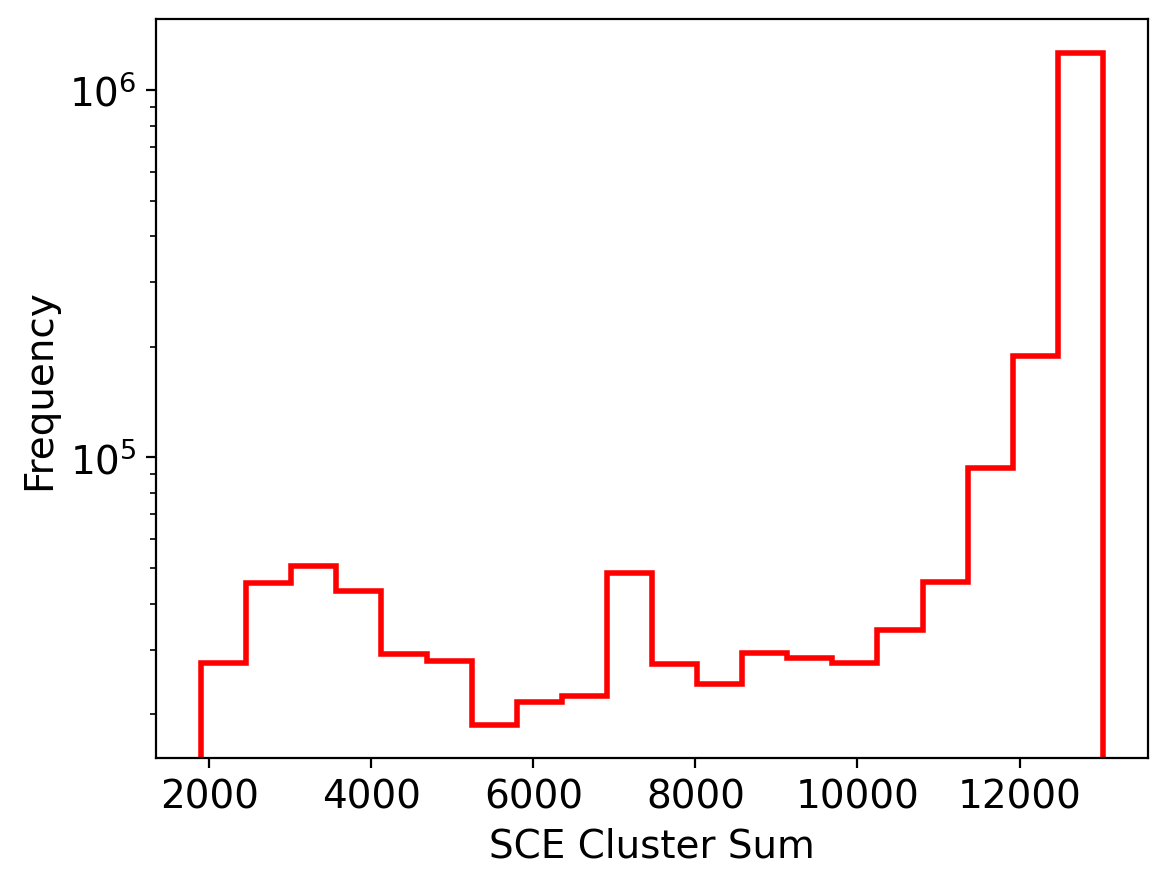

In [13]:
plt.rcParams.update({'font.size': 14})
plt.figure(dpi=200)
plt.hist(sce_sum, bins=20, color='r', label='SCE Cluster Sum', histtype='step', linewidth=2)
plt.xlabel('SCE Cluster Sum')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

Set a cutoff

In [14]:
signal_cutoff = [3500, 6000, 10000]

sce_clusters = np.zeros(number_of_points, dtype=int)
for i in range(len(sce_sum)):
    if sce_sum[i] < signal_cutoff[0]:
        sce_clusters[i] = 0
    elif sce_sum[i] < signal_cutoff[1]:
        sce_clusters[i] = 1
    elif sce_sum[i] < signal_cutoff[2]:
        sce_clusters[i] = 2
    else:
        sce_clusters[i] = 3

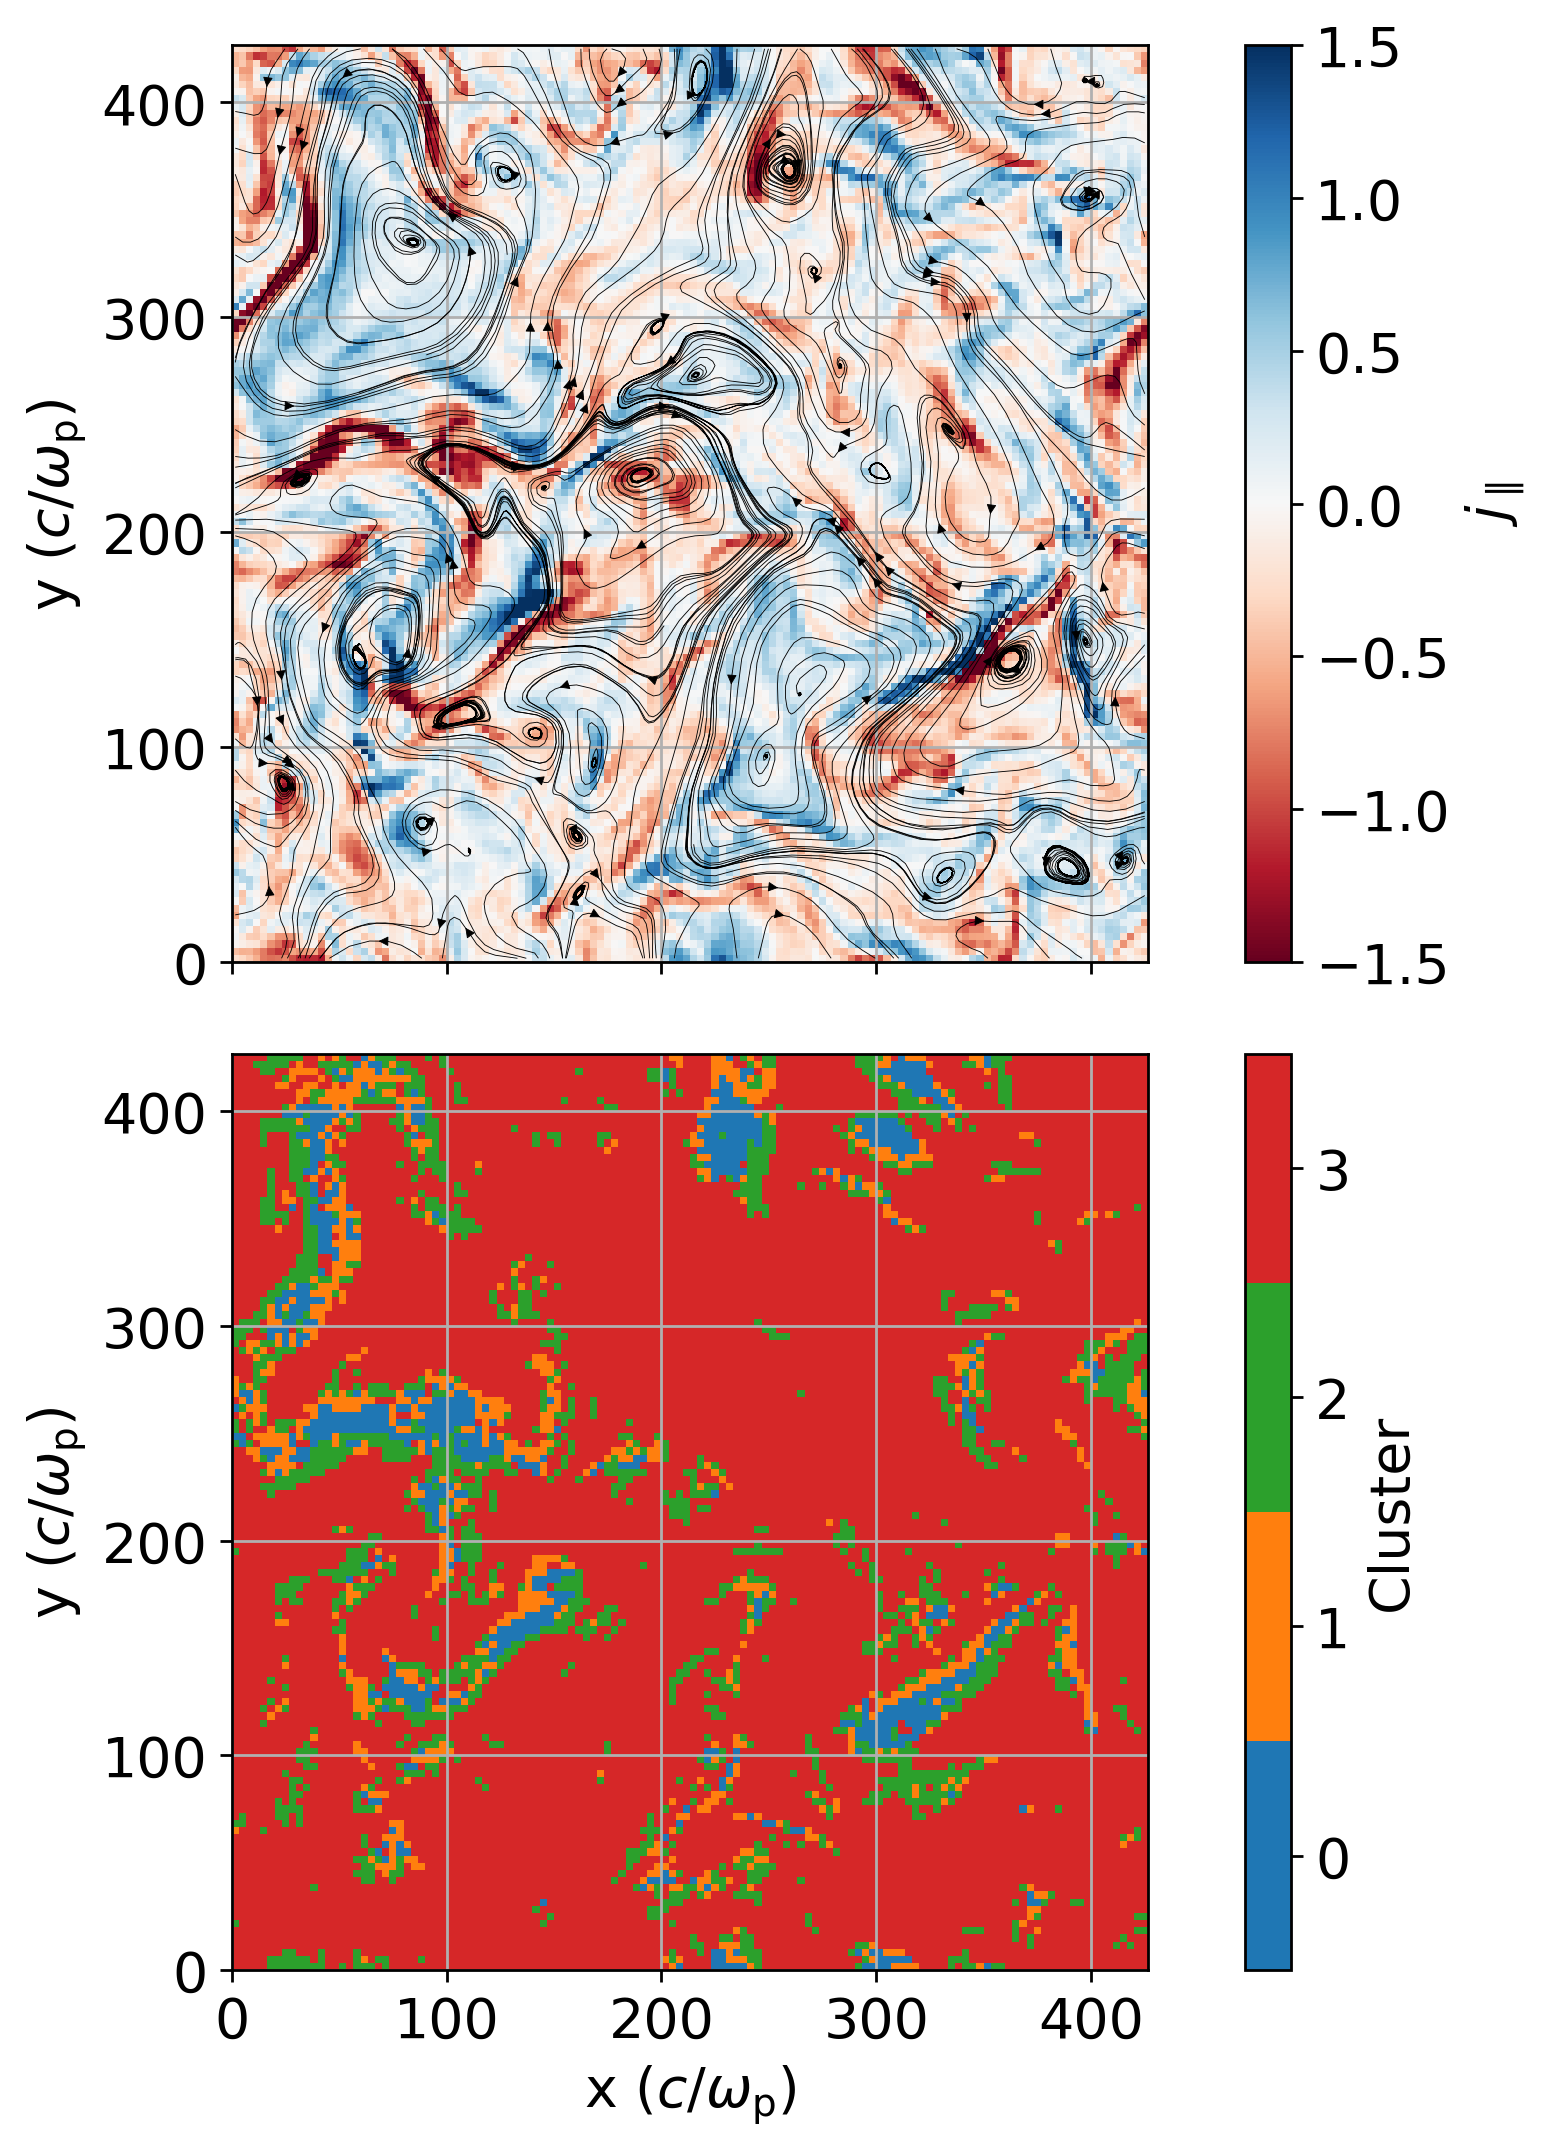

In [15]:
sce_clusters_transformed = sce_clusters.reshape((128,128,128))

plt.rcParams.update({'font.size': 16})

slice_numbers = [27]

for slice_number in slice_numbers:
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=250, sharex=True)
    fig.subplots_adjust(hspace=0.1)

    jmag_plot = ax[0].pcolormesh(j_par[slice_number], cmap='RdBu', clim=[-1.5,1.5], rasterized=True)
    fig.colorbar(jmag_plot, ax=ax[0], fraction=0.042, pad=0.05, label=r'$j_{\parallel}$', ticks=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5], location="right")
    # ax[0].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors='green', linewidths=1, linestyles='solid')
    ax[0].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1., integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    # fig.colorbar(eperp_plot, ax=ax[0], fraction=0.042, pad=0.04, label=r'$E_{\perp}$', ticks=[0, 0.1, 0.2, 0.3])
    ax[0].set_aspect('equal', adjustable='box')
    ax[0].grid()
    # ax[0].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[0].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    # ax[0].set_xlabel(r'x ($c/\omega_p$)')
    ax[0].set_ylabel(r'y ($c/\omega_{\rm p}$)')
    # ax[0].set_title(f'z = {slice_number*dx:.0f} '+ r'$c/\omega_{\rm p}$')

    cluster_plot = ax[1].pcolormesh(sce_clusters_transformed[slice_number], cmap='tab10', clim=[0,10], rasterized=True)
    cbar = fig.colorbar(cluster_plot, ax=ax[1], fraction=0.042, pad=0.05, label='Cluster', ticks=np.arange(0, len(signal_cutoff)+1)+0.5, boundaries=np.arange(0, len(signal_cutoff)+2), location="right")
    cbar.ax.set_yticklabels(np.arange(0, len(signal_cutoff)+1))
    # ax[1].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
    # ax[1].streamplot(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, bx[slice_number], by[slice_number], color='black', linewidth=0.25, broken_streamlines=False, density=1, integration_direction='both', arrowstyle='-|>', arrowsize=0.6, )
    ax[1].set_aspect('equal', adjustable='box')
    ax[1].grid()
    ax[1].set_xticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_yticks(np.arange(0, 128, 30), np.arange(0, 128*dx, 30*dx, dtype=int))
    ax[1].set_xlabel(r'x ($c/\omega_{\rm p}$)')
    ax[1].set_ylabel(r'y ($c/\omega_{\rm p}$)')

    plt.show()

## Clump finding algorithm

In [32]:
from aweSOM.combine_clumps import get_clumps
import importlib
import aweSOM.combine_clumps

importlib.reload(aweSOM.combine_clumps)
from aweSOM.combine_clumps import get_clumps

# merge all double sheet clusters into a single cluster
som_combined_double = som_labels_transformed.copy()
som_combined_double[som_labels_transformed == 2] = 1

clumps = get_clumps(som_combined_double)
clumps.sort(key=len, reverse=True)

In [18]:
print("Number of clumps: ", len(clumps))
print("Size of 10 biggest clumps: ", [len(clumps[i]) for i in range(10)])

Number of clumps:  21996
Size of 10 biggest clumps:  [1771181, 11822, 10906, 9473, 8735, 8411, 7758, 5628, 5157, 4797]


In [19]:
clumps[0][10000]

(127, 100, 3)

In [20]:
background_mask = np.where(som_labels_transformed == 6, 1, 0)
not_background_mask  = np.where(background_mask == 0, 1, 0)

# merge all clumps that contain background pixels
first_background_clump = []
this_index = 0
for clump in clumps:
    if np.any([background_mask[clump[i]] for i in range(len(clump))]):
        # print('Background found in clump')
        # print("Clump size:", len(clump))
        # continue
        if len(first_background_clump) == 0:
            index_of_first_background_clump = this_index
            first_background_clump = clump
            continue
        else:
            clumps[index_of_first_background_clump].extend(clump)
            clumps.remove(clump)
    this_index += 1

In [21]:
clump_found_array = np.zeros((nx,ny,nz),dtype=int)
clumps_dict = {}
this_clump = 0
for clump in clumps:
    if len(clump) > 5:
        for point in clump:
            clump_found_array[point] = this_clump
        clumps_dict[this_clump] = clump
        this_clump += 1

background_clusters = clump_found_array * background_mask
not_background_clusters = clump_found_array * not_background_mask

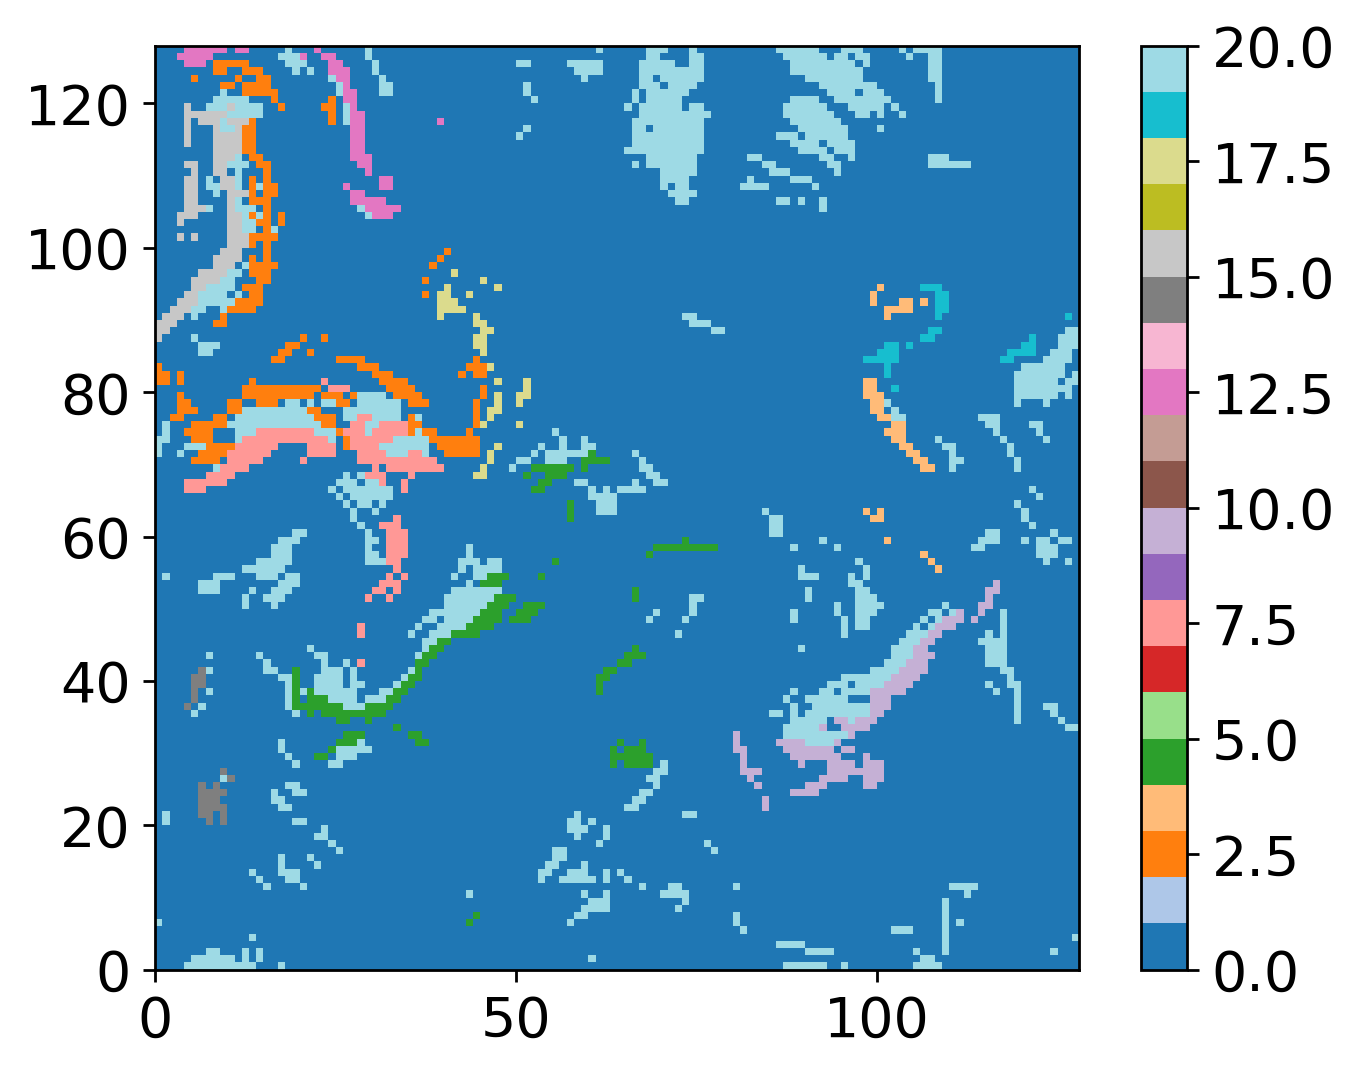

In [22]:
slice_number = 27
plt.figure(dpi=250)
plt.pcolormesh(clump_found_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
plt.gca().set_aspect('equal')
plt.colorbar()

In [23]:
# Make 3d masks based on the cluster type
double_sheets_mask = np.where(np.logical_or(som_labels_transformed == 1, som_labels_transformed == 2), 1, 0)
other_clusters_mask = np.where(np.logical_and(double_sheets_mask == 0, background_mask==0), 1, 0)
positive_sheets_mask = np.where(som_labels_transformed == 4, 1, 0)
negative_sheets_mask = np.where(som_labels_transformed == 0, 1, 0)

# Given the masks, separate the clumps into different dictionaries corresponding to the cluster type
double_sheet_dict = {}
single_sheet_dict = {}
positive_sheet_dict = {}
negative_sheet_dict = {}

for clump_index in list(clumps_dict.keys())[1:]:
    position_0 = clumps_dict[clump_index][0]
    if double_sheets_mask[position_0] == 1:
        double_sheet_dict[clump_index] = clumps_dict[clump_index]
    else:
        if positive_sheets_mask[position_0] == 1:
            positive_sheet_dict[clump_index] = clumps_dict[clump_index]
        elif negative_sheets_mask[position_0] == 1:
            negative_sheet_dict[clump_index] = clumps_dict[clump_index]
        single_sheet_dict[clump_index] = clumps_dict[clump_index]

print('Number of double sheets:', len(double_sheet_dict))
print('Number of single sheets:', len(single_sheet_dict))
print('Number of positive sheets:', len(positive_sheet_dict))
print('Number of negative sheets:', len(negative_sheet_dict))


Number of double sheets: 391
Number of single sheets: 4634
Number of positive sheets: 433
Number of negative sheets: 513


In [24]:
# Given dictionary of clumps, create a 2D array with the clumps as labels
positive_sheets_array = np.ones((nx,ny,nz), dtype=int) * -1
i = 0
for positive_key, positive_positions in positive_sheet_dict.items():
    for position in positive_positions:
        positive_sheets_array[position] = i
    i += 1

negative_sheets_array = np.ones((nx,ny,nz), dtype=int) * -1
i = 0
for negative_key, negative_positions in negative_sheet_dict.items():
    for position in negative_positions:
        negative_sheets_array[position] = i
    i += 1

double_sheets_array = np.ones((nx,ny,nz), dtype=int) * -1
i = 0
for double_key, double_positions in double_sheet_dict.items():
    for position in double_positions:
        double_sheets_array[position] = i
    i += 1


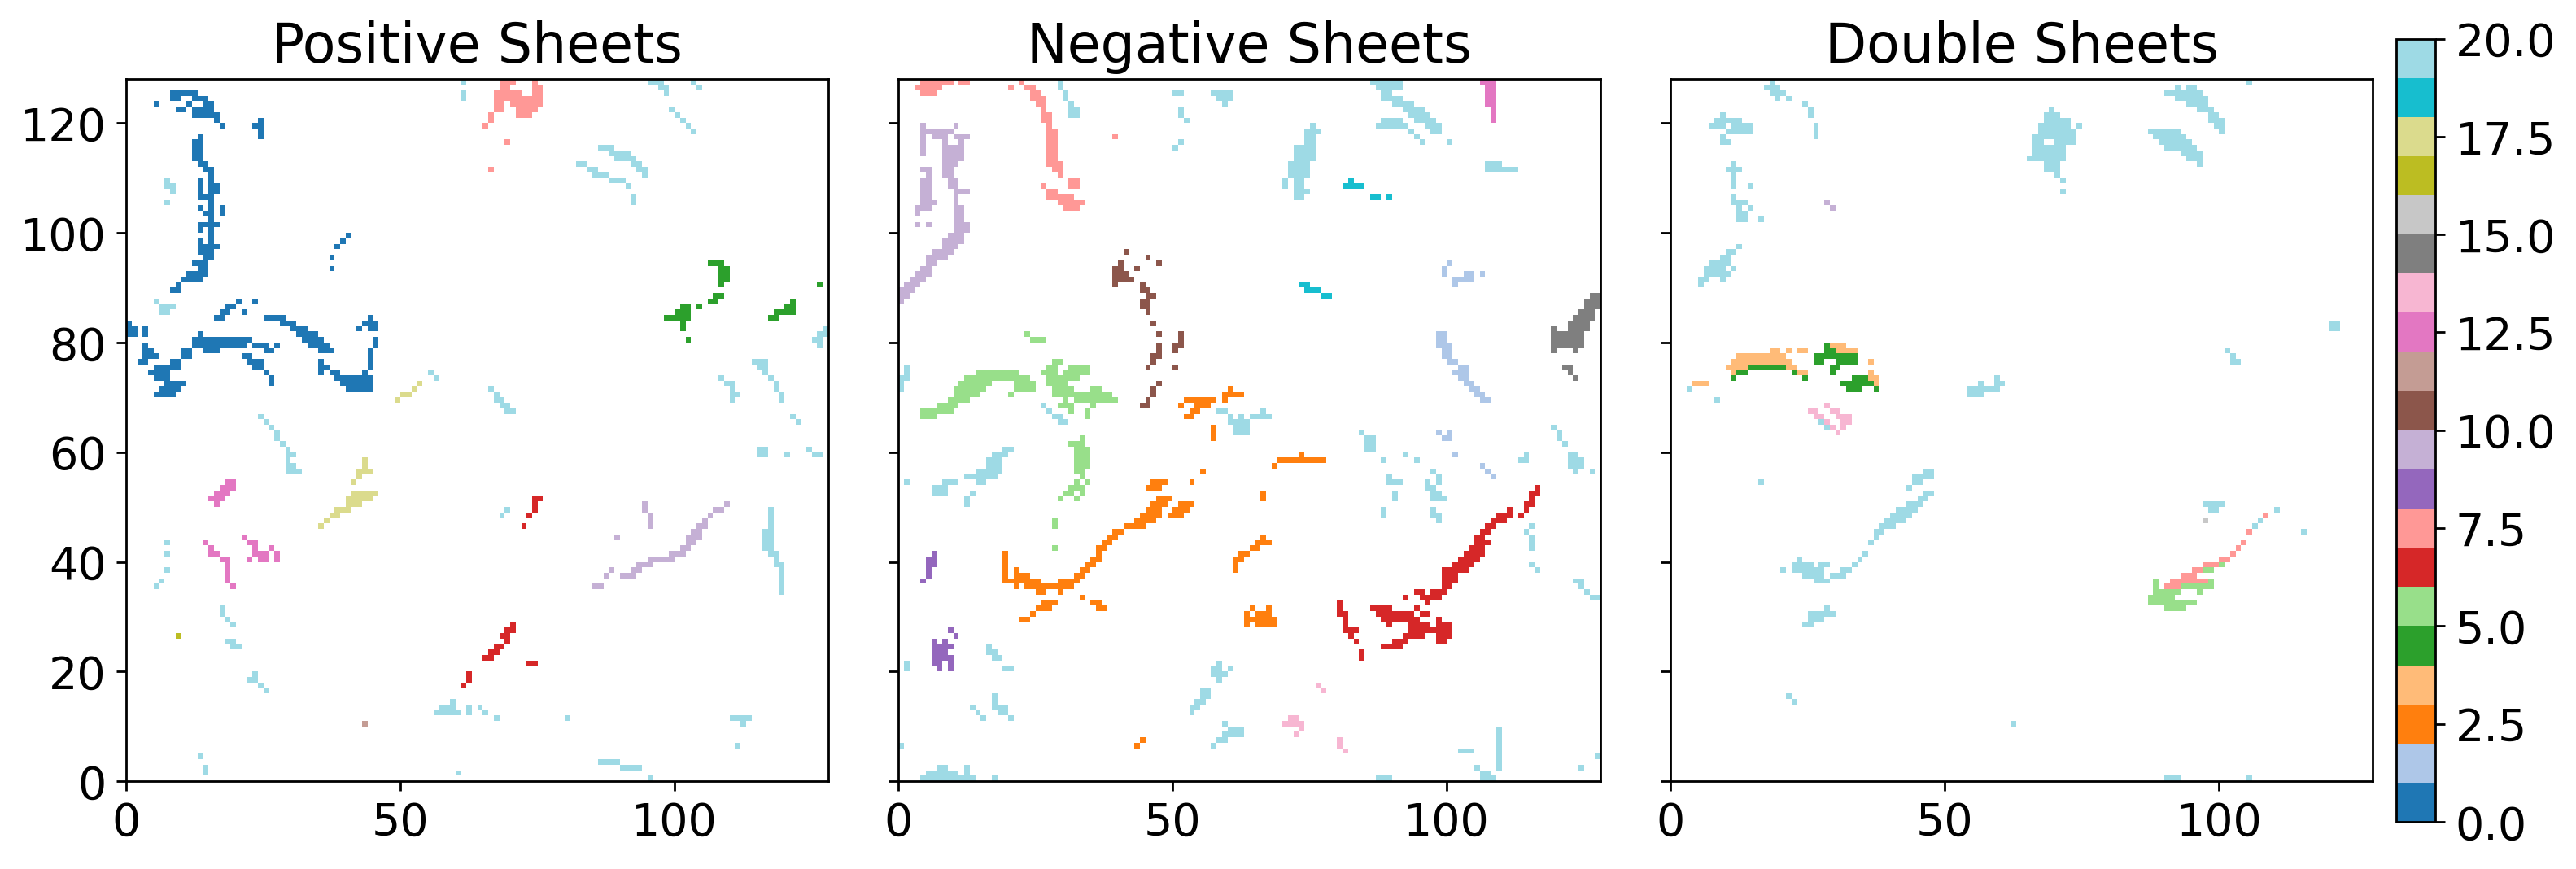

In [25]:
# slice_number = 80
fig, axs = plt.subplots(dpi=250, ncols=3, figsize=(15,5), sharey=True)
fig.subplots_adjust(wspace=0.1)
pos_plot = axs[0].pcolormesh(positive_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
axs[0].set_aspect('equal')
axs[0].set_title('Positive Sheets')
# plt.colorbar(pos_plot, ax=axs[0], fraction=0.042, pad=0.05)
neg_plot = axs[1].pcolormesh(negative_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
axs[1].set_aspect('equal')
axs[1].set_title('Negative Sheets')
# plt.colorbar(neg_plot, ax=axs[1], fraction=0.042, pad=0.05)
double_plot = axs[2].pcolormesh(double_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
axs[2].set_aspect('equal')
axs[2].set_title('Double Sheets')
plt.colorbar(double_plot, ax=axs, fraction=0.04, pad=0.01)
# plt.show()

for ax, plot in zip(axs, [pos_plot, neg_plot, double_plot]):
    plot.set_array(np.ma.masked_where(plot.get_array() == -1, plot.get_array()))

plt.show()

In [26]:
len(double_sheet_dict[8])

5157

In [27]:
def are_neighbors(pos1, pos2):
    """
    Check if two positions are neighbors based on connectivity.
    """
    if len(pos1) == 2:  # 2D 8-connectivity
        deltas = [(-1, -1), (-1, 0), (-1, 1), 
                  (0, -1),          (0, 1), 
                  (1, -1), (1, 0), (1, 1)]
    elif len(pos1) == 3:  # 3D 26-connectivity
        deltas = [(dx, dy, dz) 
                  for dx in [-1, 0, 1]
                  for dy in [-1, 0, 1]
                  for dz in [-1, 0, 1]
                  if not (dx == 0 and dy == 0 and dz == 0)]
    else:
        raise ValueError("Only 2D and 3D are supported.")

    for delta in deltas:
        neighbor = tuple(np.add(pos1, delta))
        if neighbor == pos2:
            return True
    return False

def generate_neighbors(connectivity):
    """Generate relative neighbor positions based on connectivity."""
    if connectivity == 8:  # 2D
        deltas = [(-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1), (1, 0), (1, 1)]
    elif connectivity == 26:  # 3D
        deltas = [(dx, dy, dz)
                    for dx in [-1, 0, 1]
                    for dy in [-1, 0, 1]
                    for dz in [-1, 0, 1]
                    if not (dx == 0 and dy == 0 and dz == 0)]
    else:
        raise ValueError("Unsupported connectivity. Use 8 or 26.")
    return deltas

from tqdm import tqdm
def merge_double_sheets(double_sheet_dict: dict, positive_sheet_dict: dict, negative_sheet_dict: dict):
    merged_double_sheets = dict()
    neighbor_deltas = generate_neighbors(26)

    for double_key, double_positions in double_sheet_dict.items():
        merged_clump = set()
        print('Double sheet:', double_key)

        has_positive_neighbor = False
        has_negative_neighbor = False
        
        visited_positive_keys = set()
        visited_negative_keys = set()

        for double_position in tqdm(double_positions):
            # print('Double position:', double_position)
            neighbors = [tuple(np.add(double_position, delta)) for delta in neighbor_deltas]
            
            # check positive neighbors
            for positive_key, positive_positions in positive_sheet_dict.items():
                if any([neighbor in positive_positions for neighbor in neighbors]):
                    has_positive_neighbor = True
                    merged_clump.update(positive_positions)
                    visited_positive_keys.add(positive_key)
                    break
                # if any(any(are_neighbors(double_position, posp) for posp in positive_positions):
                #     has_positive_neighbor = True
                #     merged_clump.update(positive_positions)
                #     visited_positive_keys.add(positive_key)
                #     break

            if has_positive_neighbor:
                # check negative neighbors
                for negative_key, negative_positions in negative_sheet_dict.items():
                    if any([neighbor in negative_positions for neighbor in neighbors]):
                        has_negative_neighbor = True
                        merged_clump.update(negative_positions)
                        visited_negative_keys.add(negative_key)
                        break
                    # if any(are_neighbors(double_position, negp) for negp in negative_positions):
                    #     has_negative_neighbor = True
                    #     merged_clump.update(negative_positions)
                    #     visited_negative_keys.add(negative_key)
                    #     break 

            # break condition stops the loop as soon as one positive and one negative neighbor is found
            # but we want to merge all the clumps that are connected to the double sheet
            # if has_positive_neighbor and has_negative_neighbor:
            #     break

        if has_positive_neighbor and has_negative_neighbor:
            merged_clump.update(double_positions)
            merged_double_sheets[double_key] = merged_clump

            # remove the visited keys to avoid overlap between clusters
            for positive_key in visited_positive_keys:
                del positive_sheet_dict[positive_key]
            for negative_key in visited_negative_keys:
                del negative_sheet_dict[negative_key]
    
    return merged_double_sheets    

merged_double_sheets = merge_double_sheets(double_sheet_dict, positive_sheet_dict, negative_sheet_dict)
merged_double_sheets_array = np.ones((nx,ny,nz),dtype=int) * -1
i = 0
for double_key, double_positions in merged_double_sheets.items():
    for position in double_positions:
        merged_double_sheets_array[position] = i
    i += 1

Double sheet: 8


  0%|          | 0/5157 [00:00<?, ?it/s]

100%|██████████| 5157/5157 [08:38<00:00,  9.95it/s]


Double sheet: 11


100%|██████████| 3987/3987 [04:29<00:00, 14.79it/s]


...

100%|██████████| 6/6 [00:00<00:00, 46.72it/s]


Double sheet: 4963


100%|██████████| 6/6 [00:00<00:00, 56.71it/s]


Double sheet: 4978


100%|██████████| 6/6 [00:00<00:00, 56.03it/s]


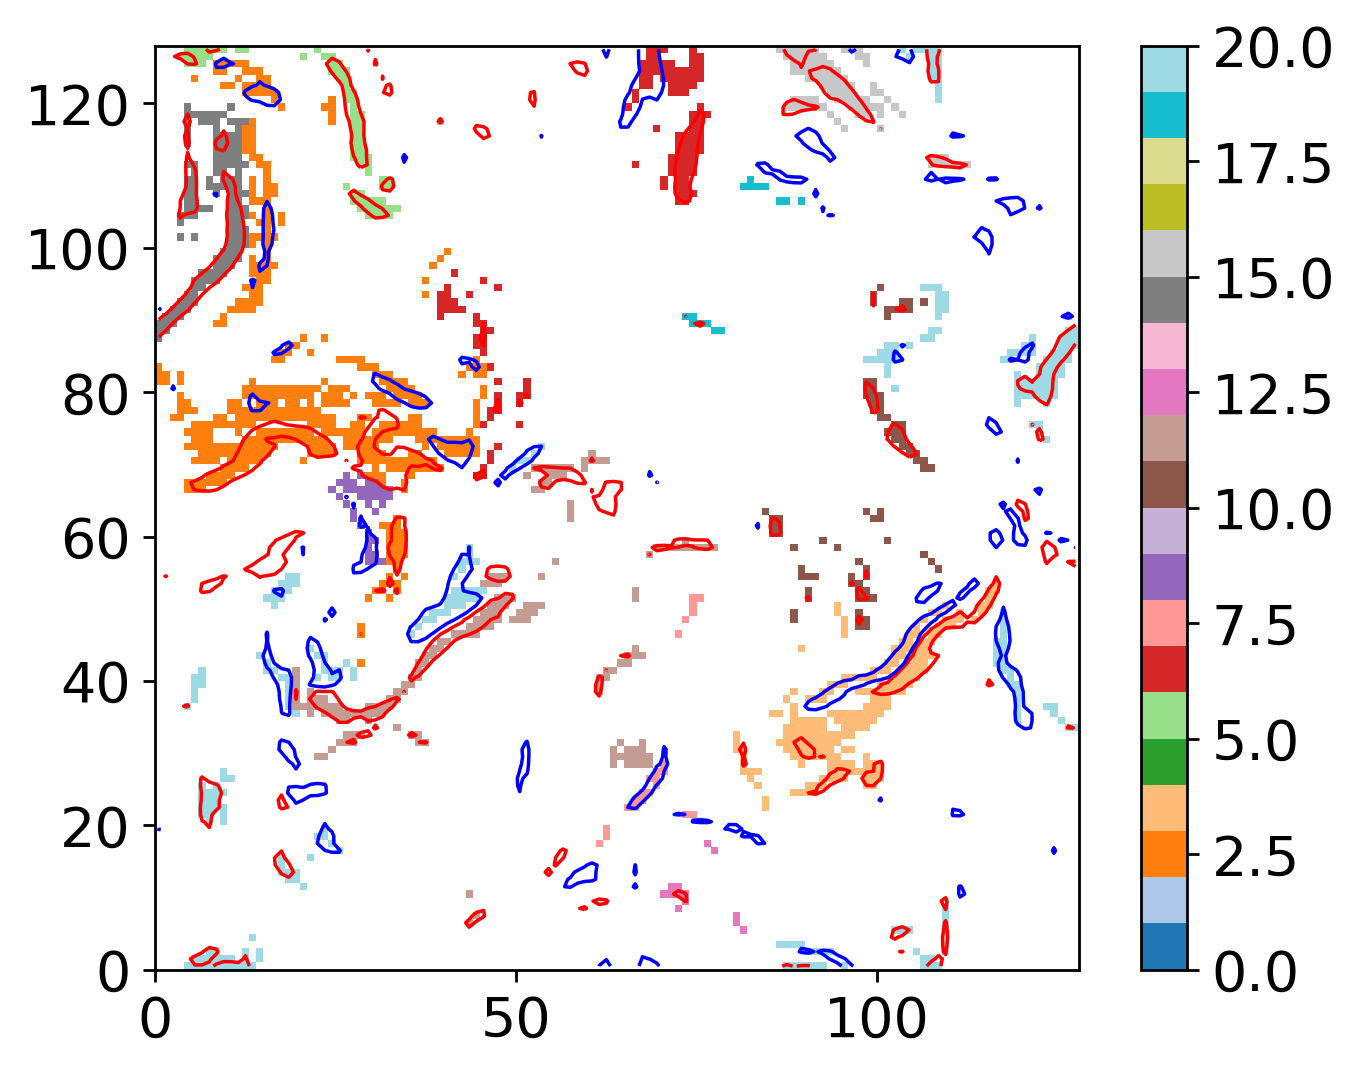

In [29]:
plt.figure(dpi=250)
plt.pcolormesh(np.ma.masked_where(merged_double_sheets_array == -1, merged_double_sheets_array)[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
plt.colorbar()
plt.contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
plt.gca().set_aspect('equal')
plt.show()

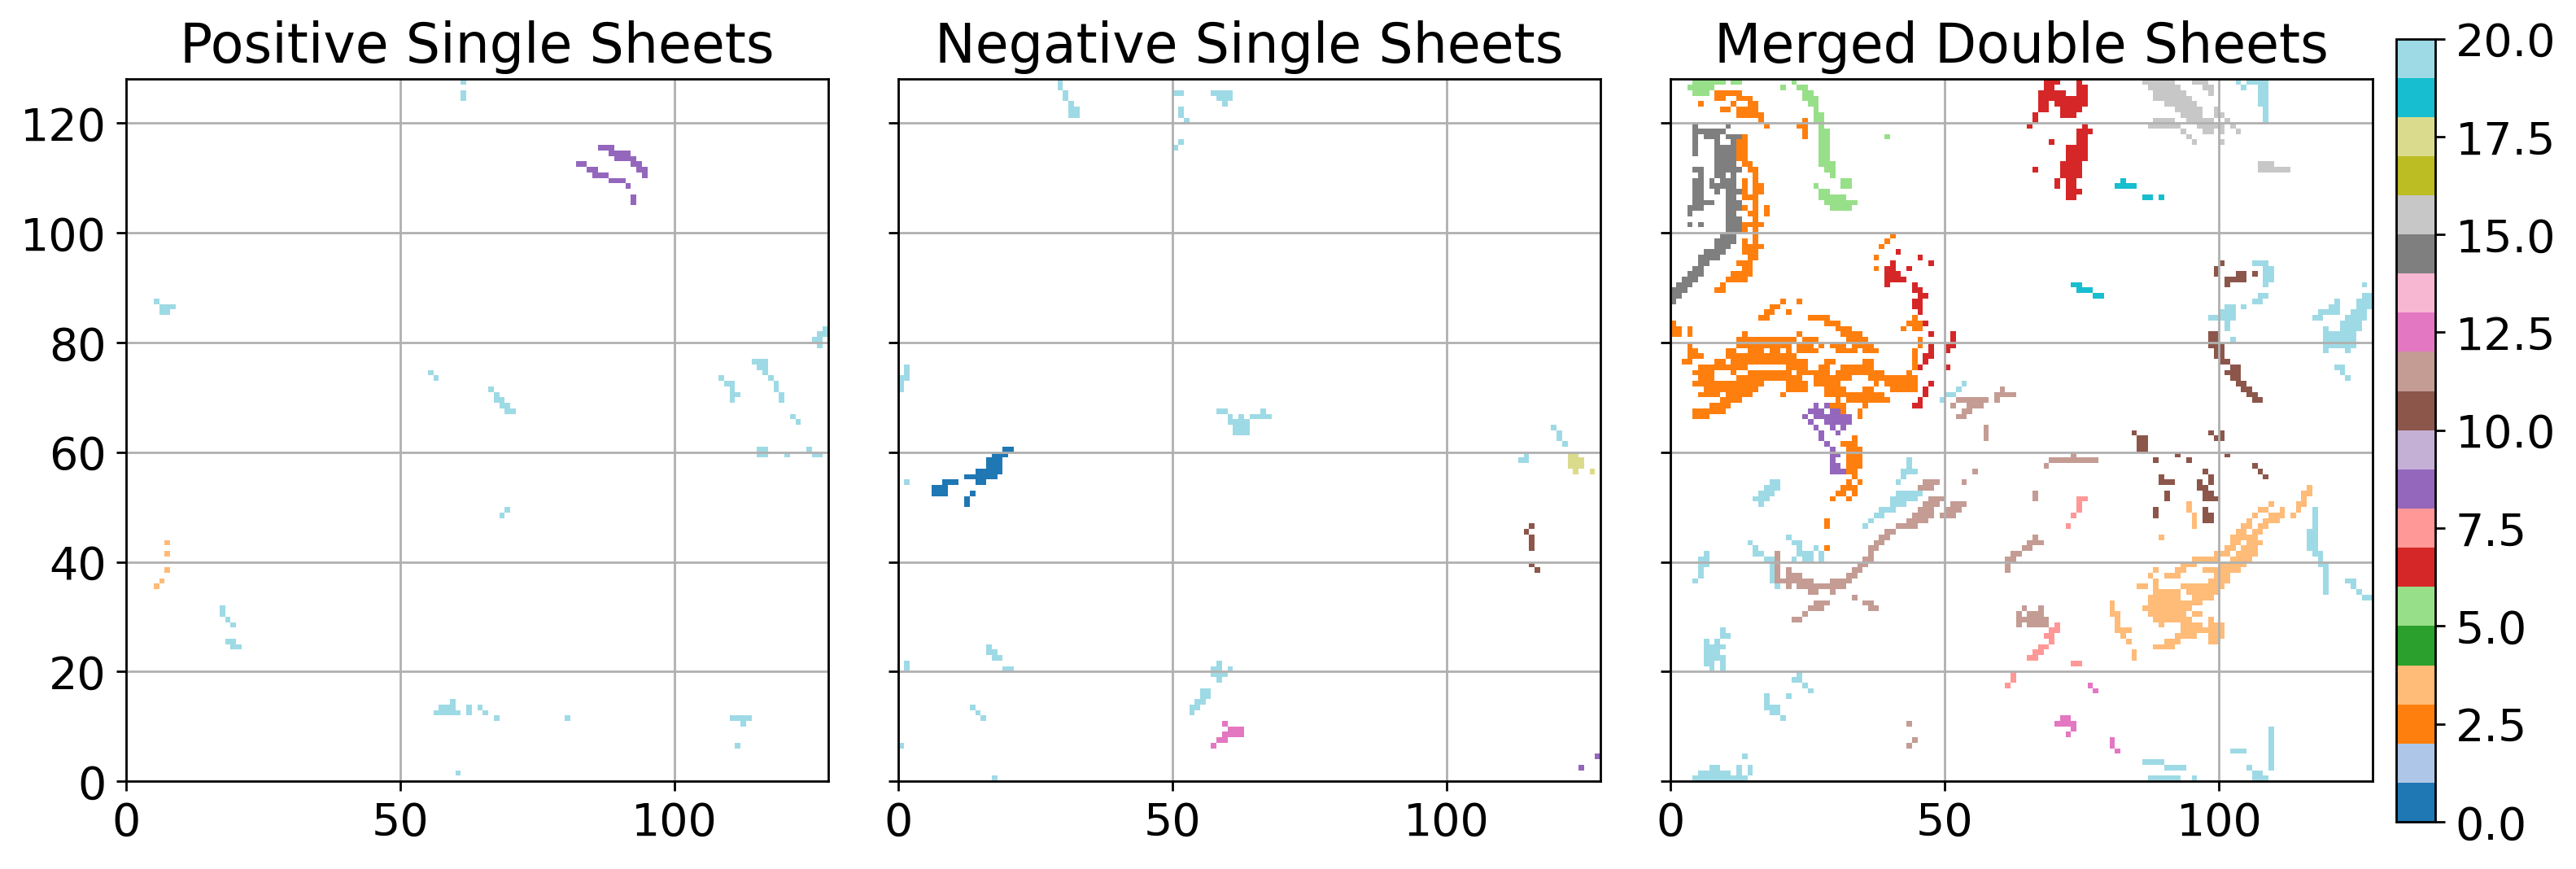

In [31]:
# Plot the merged double sheets and the single sheets
positive_sheets_array = np.ones((nx,ny,nz), dtype=int) * -1
i = 0
for positive_key, positive_positions in positive_sheet_dict.items():
    for position in positive_positions:
        positive_sheets_array[position] = i
    i += 1

negative_sheets_array = np.ones((nx,ny,nz), dtype=int) * -1
i = 0
for negative_key, negative_positions in negative_sheet_dict.items():
    for position in negative_positions:
        negative_sheets_array[position] = i
    i += 1

fig, axs = plt.subplots(dpi=250, ncols=3, figsize=(15,5), sharey=True)
fig.subplots_adjust(wspace=0.1)
pos_plot = axs[0].pcolormesh(positive_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
# axs[0].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
axs[0].set_aspect('equal')
axs[0].set_title('Positive Single Sheets')
axs[0].grid()
# plt.colorbar(pos_plot, ax=axs[0], fraction=0.042, pad=0.05)
neg_plot = axs[1].pcolormesh(negative_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
# axs[1].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
axs[1].set_aspect('equal')
axs[1].set_title('Negative Single Sheets')
axs[1].grid()
# plt.colorbar(neg_plot, ax=axs[1], fraction=0.042, pad=0.05)
double_plot = axs[2].pcolormesh(merged_double_sheets_array[slice_number], cmap='tab20', clim=[0,20], rasterized=True)
# axs[2].contour(np.arange(0, nx)+0.5, np.arange(0, ny)+0.5, j_par[slice_number,:,:], levels=[-2.*j_par_rms,2.*j_par_rms], colors=['red','blue'], linewidths=1, linestyles='solid')
axs[2].set_aspect('equal')
axs[2].set_title('Merged Double Sheets')
axs[2].grid()
plt.colorbar(double_plot, ax=axs, fraction=0.04, pad=0.01)

for ax, plot in zip(axs, [pos_plot, neg_plot, double_plot]):
    plot.set_array(np.ma.masked_where(plot.get_array() == -1, plot.get_array()))
plt.show()

## Optional - Generate different sets of features

**Under Construction**